# 1D Ideal MHD in Dedalus

This notebook defines and solves the **1D ideal MHD equations** in Dedalus using a periodic Fourier domain.
## Mathematical Formulation

The 1D ideal MHD equations for inviscid, compressible flow are:

$$\rho_t + (\rho u_1)_x = 0$$
$$(\rho u_i)_t + (\rho u_1 u_i + (p + B^2 / 2) \delta_{i1} - B_1 B_i)_x = 0$$
$$E_t + (u_1 (E + p + B^2 / 2) - B_1 (u \cdot B))_x = 0$$
$$(B_i)_t + (u_1 B_i - u_i B_1)_x = 0$$

The fluid is an ideal gas with pressure given by $p=\rho (\gamma-1)e$ where $e$ is internal energy.

The conservative variables are
$$Q = [\rho, m_x, m_y, m_z, B_x, B_y, B_z, E], \quad m_i = \rho u_i.$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3
import h5py
from pathlib import Path
import shutil
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import random

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Domain and fields

We use a 1D periodic Fourier basis in $x\in[-1,1]$.

In [2]:
# Parameters (aligned with shocktube.ipynb case)
gamma = 3.0
N = 512
Lx = 8.0   # domain [-4, 4]

# Coordinate, distributor, basis
xcoord = d3.Coordinate('x')
dist = d3.Distributor(xcoord, dtype=np.float64)
xbasis = d3.RealFourier(xcoord, size=N, bounds=(-Lx/2, Lx/2), dealias=3/2)
x = dist.local_grid(xbasis)

# Conservative fields
rho = dist.Field(name='rho', bases=xbasis)
mx  = dist.Field(name='mx',  bases=xbasis)
my  = dist.Field(name='my',  bases=xbasis)
mz  = dist.Field(name='mz',  bases=xbasis)
Bx  = dist.Field(name='Bx',  bases=xbasis)
By  = dist.Field(name='By',  bases=xbasis)
Bz  = dist.Field(name='Bz',  bases=xbasis)
E   = dist.Field(name='E',   bases=xbasis)

dx = lambda A: d3.Differentiate(A, xcoord)

ux = mx / rho
uy = my / rho
uz = mz / rho
B2 = Bx*Bx + By*By + Bz*Bz
u2 = ux*ux + uy*uy + uz*uz
p = (gamma - 1) * (E - 0.5*rho*u2 - 0.5*B2)

## 1D MHD equations in conservative form (with viscosity and resistivity)

We evolve
$$
Q = [\rho, m_x, m_y, m_z, B_x, B_y, B_z, E], \qquad m_i = \rho u_i,
$$
with
$$
\partial_t Q + \partial_x F(Q) = S_{\mathrm{diss}}.
$$

### Ideal (hyperbolic) fluxes
$$
\begin{aligned}
F_{\rho} &= m_x,\\
F_{m_x} &= m_x u_x + p + \frac{B^2}{2} - B_x^2,\\
F_{m_y} &= m_y u_x - B_x B_y,\\
F_{m_z} &= m_z u_x - B_x B_z,\\
F_{B_x} &= 0,\\
F_{B_y} &= u_x B_y - u_y B_x,\\
F_{B_z} &= u_x B_z - u_z B_x,\\
F_E &= u_x\!\left(E + p + \frac{B^2}{2}\right) - B_x (u \cdot B).
\end{aligned}
$$

where
$$
B^2 = B_x^2 + B_y^2 + B_z^2, \qquad
u \cdot B = u_x B_x + u_y B_y + u_z B_z.
$$

### Dissipation model used in this notebook
- $\mu_{\mathrm{visc}}$: viscosity coefficient (Newtonian 1D closure)
- $\eta$: magnetic resistivity (diffusion of $B$ + Ohmic heating)

$$
\tau_{xx} = \frac{4}{3}\mu_{\mathrm{visc}}\,\partial_x u_x, \qquad
\tau_{xy} = \mu_{\mathrm{visc}}\,\partial_x u_y, \qquad
\tau_{xz} = \mu_{\mathrm{visc}}\,\partial_x u_z.
$$

$$
J^2 \approx (\partial_x B_y)^2 + (\partial_x B_z)^2.
$$

### Full equations solved
$$
\begin{aligned}
\partial_t \rho &= -\partial_x(F_\rho),\\
\partial_t m_x &= -\partial_x(F_{m_x} - \tau_{xx}),\\
\partial_t m_y &= -\partial_x(F_{m_y} - \tau_{xy}),\\
\partial_t m_z &= -\partial_x(F_{m_z} - \tau_{xz}),\\
\partial_t B_x &= -\partial_x(F_{B_x}) + \eta\,\partial_{xx} B_x,\\
\partial_t B_y &= -\partial_x(F_{B_y}) + \eta\,\partial_{xx} B_y,\\
\partial_t B_z &= -\partial_x(F_{B_z}) + \eta\,\partial_{xx} B_z,\\
\partial_t E &=
-\partial_x\!\left(F_E - (u_x\tau_{xx}+u_y\tau_{xy}+u_z\tau_{xz})\right)
+ \eta\,J^2.
\end{aligned}
$$

So, while the base flux is ideal MHD, the run is a **non-ideal extension** with viscous momentum/energy diffusion and resistive magnetic diffusion/heating.


In [3]:
u_dot_B = ux*Bx + uy*By + uz*Bz

Frho = mx
Fmx  = mx*ux + p + 0.5*B2 - Bx*Bx
Fmy  = my*ux - Bx*By
Fmz  = mz*ux - Bx*Bz
FBx  = 0*Bx
FBy  = ux*By - uy*Bx
FBz  = ux*Bz - uz*Bx
FE   = ux*(E + p + 0.5*B2) - Bx*u_dot_B

# Physical dissipation coefficients
mu_visc = 2.0e-3   # kinematic viscosity-like coefficient
eta = 2.0e-3       # magnetic resistivity

# 1D viscous stresses (Newtonian closure)
dux_dx = dx(ux)
duy_dx = dx(uy)
duz_dx = dx(uz)
tau_xx = (4.0/3.0) * mu_visc * dux_dx
tau_xy = mu_visc * duy_dx
tau_xz = mu_visc * duz_dx

# 1D current-squared proxy for Ohmic heating (By/Bz vary in x)
J2 = dx(By)*dx(By) + dx(Bz)*dx(Bz)

problem_namespace = dict(locals())
problem_namespace.pop('dt', None)  # avoid collision with Dedalus dt() operator

problem = d3.IVP([rho, mx, my, mz, Bx, By, Bz, E], namespace=problem_namespace)
problem.add_equation("dt(rho) = -dx(Frho)")
problem.add_equation("dt(mx)  = -dx(Fmx - tau_xx)")
problem.add_equation("dt(my)  = -dx(Fmy - tau_xy)")
problem.add_equation("dt(mz)  = -dx(Fmz - tau_xz)")
problem.add_equation("dt(Bx)  = -dx(FBx) + eta*dx(dx(Bx))")
problem.add_equation("dt(By)  = -dx(FBy) + eta*dx(dx(By))")
problem.add_equation("dt(Bz)  = -dx(FBz) + eta*dx(dx(Bz))")
problem.add_equation("dt(E)   = -dx(FE - (ux*tau_xx + uy*tau_xy + uz*tau_xz)) + eta*J2")

solver = problem.build_solver(d3.RK222)
solver.stop_sim_time = 4.0 #2.4 #0.6

2026-02-21 11:21:00,431 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 6.5e+01/s


In [4]:
# Initial condition aligned with shocktube.ipynb choices

# Build ICs at the current field scale to avoid shape mismatches
current_scale = rho['g'].shape[0] / N
x_ic = dist.local_grid(xbasis, scale=current_scale)

EPS = 0.1
EPS2 = 0.02
K = 6
SIGMA = 0.5

rho0 = 1 + EPS2*np.sin(K * x_ic) + EPS*np.exp(-(x_ic**2)/(2*SIGMA**2)) - EPS*np.exp(-((x_ic+3)**2)/(2*SIGMA**2))
p0 = rho0**gamma

Bx0 = 1 + EPS2*np.sin(K * x_ic) + EPS*np.exp(-(x_ic**2)/(2*SIGMA**2))
By0 = 1 + EPS2*np.sin(K * x_ic) + EPS*np.exp(-(x_ic**2)/(2*SIGMA**2))
Bz0 = np.ones_like(x_ic)

ux0 = np.zeros_like(x_ic)
uy0 = np.zeros_like(x_ic)
uz0 = np.zeros_like(x_ic)

rho['g'] = rho0
mx['g']  = rho0 * ux0
my['g']  = rho0 * uy0
mz['g']  = rho0 * uz0
Bx['g']  = Bx0
By['g']  = By0
Bz['g']  = Bz0
E['g']   = p0/(gamma-1) + 0.5*rho0*(ux0**2 + uy0**2 + uz0**2) + 0.5*(Bx0**2 + By0**2 + Bz0**2)

# Canonical initial profiles for later plotting (single source of truth)
x_init_profile = x_ic.copy()
rho_init_profile = rho0.copy()
Bx_init_profile = Bx0.copy()
By_init_profile = By0.copy()
p_init_profile = p0.copy()

print('Initial condition set')

Initial condition set


## Time stepping, CFL, and HDF5 analysis outputs

This run uses Dedalus built-ins for both stability control and data output:

- `d3.CFL(...)` computes an adaptive timestep from a velocity field.
- `solver.evaluator.add_file_handler(...)` writes analysis tasks directly to HDF5 (Tutorial 4 style).

For CFL diagnostics we track
$$\Delta t \le C_{\mathrm{CFL}}\,\frac{\Delta x}{\max_x\left(|u_x| + c_f\right)}$$
in sampled arrays for plotting, while full field snapshots are written to `.h5` files rather than appended in Python lists.

In [5]:
# Time integration with Dedalus built-in CFL + file handlers (Tutorial 4 style)
save_every = 10
diag_every = 20
print_every = 100

# CFL settings (more conservative for oscillation control)
cfl_safety = 0.30
dt_min = 1e-6
dt_max = 2e-3 #8.0e-4
dx_grid = Lx / N

# Periodic spectral filtering (repo-style low-pass technique)
apply_filter_every = 20
filter_scale = 0.92

# Clean previous outputs so each run is self-consistent
output_dir = Path('analysis_mhd')
if output_dir.exists():
    shutil.rmtree(output_dir)

# Analysis handler: save state + derived fields to HDF5
analysis = solver.evaluator.add_file_handler(str(output_dir), iter=save_every, max_writes=800)
analysis.add_tasks(solver.state, layout='g')
analysis.add_task(mx / rho, layout='g', name='ux')
analysis.add_task(p, layout='g', name='p')

# Built-in CFL controller
u_vec = dist.VectorField(xcoord, name='u_vec', bases=xbasis)
current_scale = mx['g'].shape[0] / N
u_vec.change_scales(current_scale)
CFL = d3.CFL(
    solver,
    initial_dt=dt_max,
    cadence=1,
    safety=cfl_safety,
    max_dt=dt_max,
    min_dt=dt_min,
    max_change=1.1,
    min_change=0.5,
    threshold=0.05,
    )
CFL.add_velocity(u_vec)

# Built-in flow diagnostics for characteristic speed estimate
fast_speed_expr = np.abs(mx / rho) + np.sqrt(gamma * p / rho + (Bx*Bx + By*By + Bz*Bz) / rho)
flow = d3.GlobalFlowProperty(solver, cadence=diag_every)
flow.add_property(fast_speed_expr, name='char_speed')

if not solver.proceed:
    print("Solver is already at stop time.")
    print("Please rerun Cell 6 (build solver) and Cell 7 (initial condition), then run this cell again.")
else:
    # Sampled CFL diagnostics only (small arrays)
    iter_diag = []
    t_diag = []
    dt_diag = []
    cfl_diag = []
    maxspeed_diag = []

    print(f"Starting loop at iter={solver.iteration}, t={solver.sim_time:.5f}", flush=True)
    while solver.proceed:
        # Update velocity field used by CFL controller
        rho_now = np.maximum(rho['g'], 1e-12)
        u_vec['g'][0] = mx['g'] / rho_now

        dt_step = CFL.compute_timestep()
        solver.step(dt_step)

        # Mild high-k cleanup to reduce rapid oscillations
        if solver.iteration % apply_filter_every == 0:
            for fld in [rho, mx, my, mz, Bx, By, Bz, E]:
                fld.low_pass_filter(scales=filter_scale)

        if solver.iteration % print_every == 0:
            max_speed = flow.max('char_speed')
            cfl_eff = max_speed * dt_step / dx_grid
            print(
                f"iter={solver.iteration:6d}  t={solver.sim_time:.5f}  dt={dt_step:.2e}  CFL={cfl_eff:.3f}  max|u|+cf={max_speed:.3f}",
                flush=True,
            )

        if solver.iteration % diag_every == 0 or not solver.proceed:
            max_speed = flow.max('char_speed')
            cfl_eff = max_speed * dt_step / dx_grid
            iter_diag.append(solver.iteration)
            t_diag.append(solver.sim_time)
            dt_diag.append(dt_step)
            cfl_diag.append(cfl_eff)
            maxspeed_diag.append(max_speed)

    analysis_files = sorted(output_dir.glob('analysis_mhd_s*.h5'))
    print(f"Finished: iter={solver.iteration}, t={solver.sim_time:.4f}", flush=True)
    print(f"Wrote {len(analysis_files)} analysis set file(s) under: {output_dir}/")

Starting loop at iter=0, t=0.00000
iter=   100  t=0.20000  dt=2.00e-03  CFL=0.333  max|u|+cf=2.602
iter=   200  t=0.40000  dt=2.00e-03  CFL=0.333  max|u|+cf=2.602
iter=   300  t=0.60000  dt=2.00e-03  CFL=0.333  max|u|+cf=2.599
iter=   400  t=0.80000  dt=2.00e-03  CFL=0.333  max|u|+cf=2.604
iter=   500  t=1.00000  dt=2.00e-03  CFL=0.337  max|u|+cf=2.632
iter=   600  t=1.20000  dt=2.00e-03  CFL=0.332  max|u|+cf=2.592
iter=   700  t=1.40000  dt=2.00e-03  CFL=0.333  max|u|+cf=2.602
iter=   800  t=1.60000  dt=2.00e-03  CFL=0.333  max|u|+cf=2.604
iter=   900  t=1.80000  dt=2.00e-03  CFL=0.332  max|u|+cf=2.592
iter=  1000  t=2.00000  dt=2.00e-03  CFL=0.331  max|u|+cf=2.583
iter=  1100  t=2.20000  dt=2.00e-03  CFL=0.333  max|u|+cf=2.601
iter=  1200  t=2.40000  dt=2.00e-03  CFL=0.335  max|u|+cf=2.616
iter=  1300  t=2.60000  dt=2.00e-03  CFL=0.338  max|u|+cf=2.642
iter=  1400  t=2.80000  dt=2.00e-03  CFL=0.333  max|u|+cf=2.600
iter=  1500  t=3.00000  dt=2.00e-03  CFL=0.331  max|u|+cf=2.587
iter=

## What gets saved and what is monitored

During the run:
- fields are written to `analysis_mhd/*.h5` through a Dedalus `FileHandler`,
- timestep is chosen by built-in `d3.CFL`,
- sampled diagnostics track iteration, time, `dt`, effective CFL, and a max characteristic-speed estimate.

After the run, plotting cells read the field history directly from the HDF5 sets.

In [6]:
# Quick HDF5 inspection: files, tasks, and time span
analysis_dir = Path('analysis_mhd')
analysis_files = sorted(analysis_dir.glob('analysis_mhd_s*.h5'))

if len(analysis_files) == 0:
    print("No analysis HDF5 files found. Run Cell 9 first.")
else:
    print(f"Found {len(analysis_files)} set file(s):")
    for fp in analysis_files:
        print(f"  - {fp}")

    with h5py.File(analysis_files[0], mode='r') as f0:
        task_names = list(f0['tasks'].keys())
    print("\nTasks in file handler:")
    for name in task_names:
        print(f"  - {name}")

    # Aggregate time info across all sets (using rho as reference)
    t_all = []
    for fp in analysis_files:
        with h5py.File(fp, mode='r') as f:
            t_all.append(np.asarray(f['tasks']['rho'].dims[0]['sim_time']))
    t_all = np.concatenate(t_all)

    print("\nTime coverage:")
    print(f"  writes: {len(t_all)}")
    print(f"  t_min: {t_all.min():.5f}")
    print(f"  t_max: {t_all.max():.5f}")
    if len(t_all) > 1:
        dtw = np.diff(t_all)
        print(f"  write dt range: [{dtw.min():.5e}, {dtw.max():.5e}]")

Found 1 set file(s):
  - analysis_mhd/analysis_mhd_s1.h5

Tasks in file handler:
  - Bx
  - By
  - Bz
  - E
  - mx
  - my
  - mz
  - p
  - rho
  - ux

Time coverage:
  writes: 201
  t_min: 0.00000
  t_max: 4.00000
  write dt range: [2.00000e-02, 2.00000e-02]


## Initial vs final comparison (shocktube replica)

This plot compares initial profiles stored in Cell 7 with the final state loaded from `analysis_mhd/*.h5` (no formula redefinition in this cell).

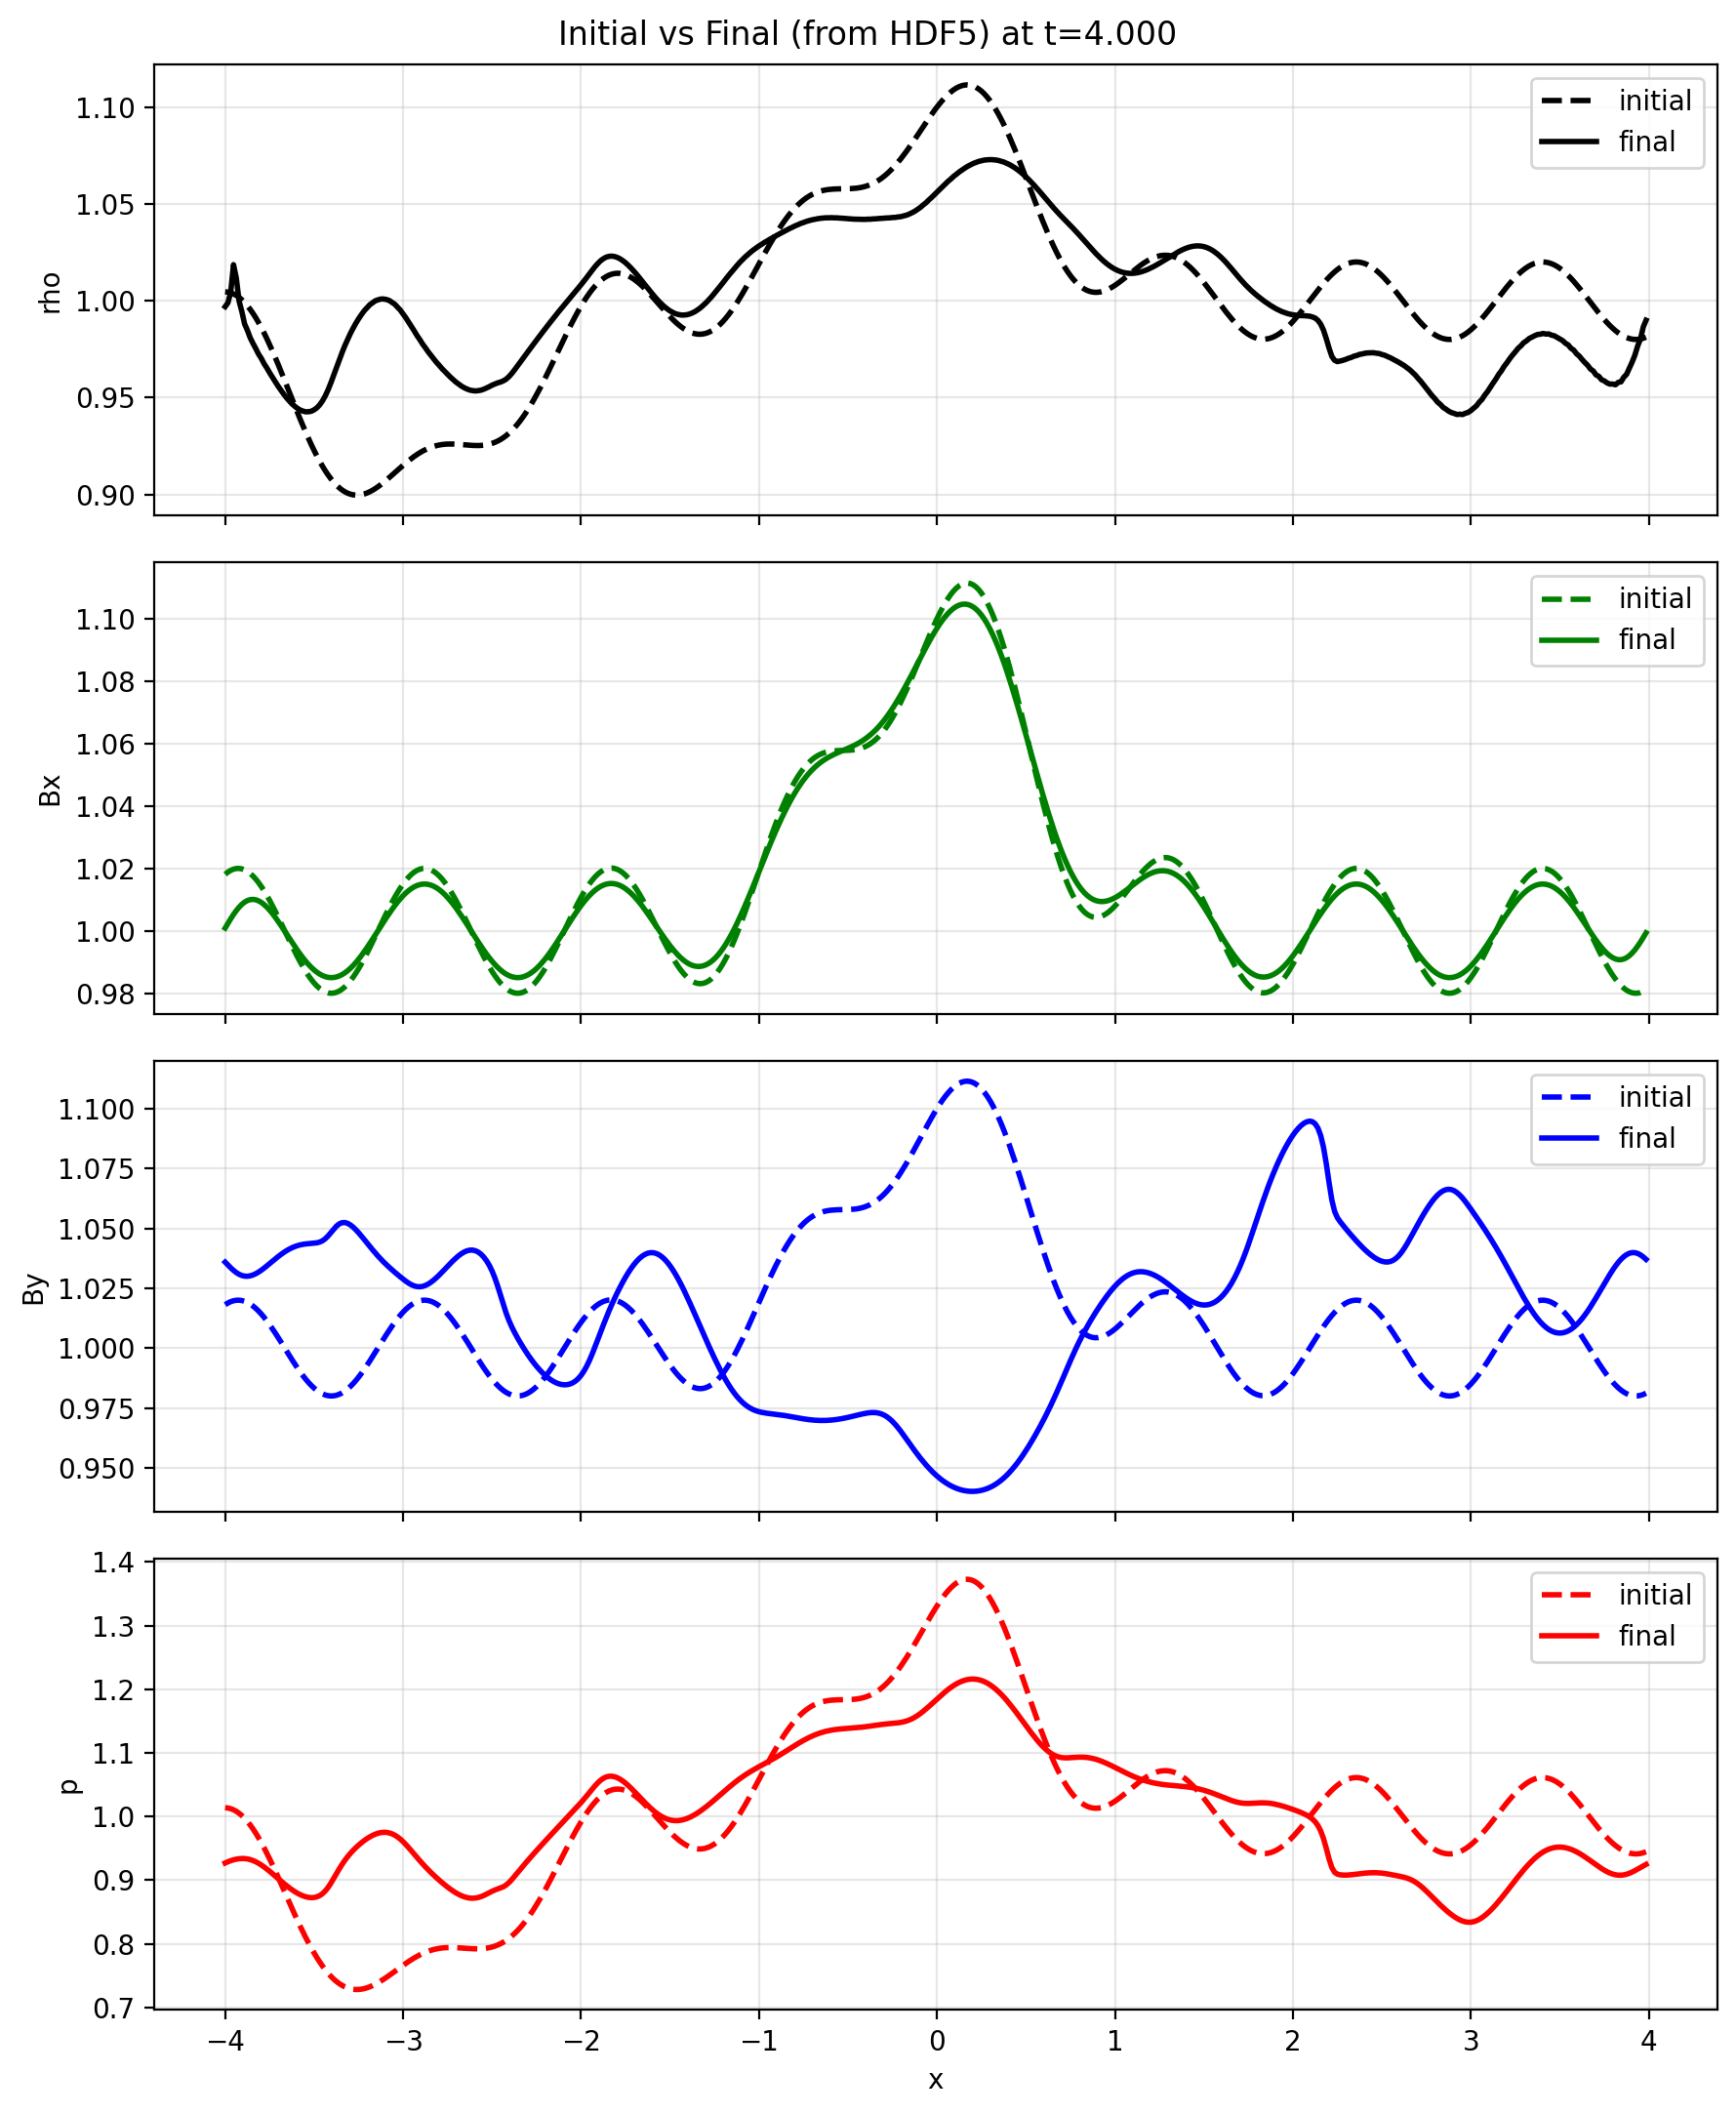

In [7]:
# Initial-vs-final comparison using IC profiles from Cell 7 and final state from HDF5
analysis_dir = Path('analysis_mhd')
analysis_files = sorted(analysis_dir.glob('analysis_mhd_s*.h5'))

if len(analysis_files) == 0:
    print("No analysis HDF5 files found. Run Cell 9 first.")
else:
    # Load final write from the last set file
    with h5py.File(analysis_files[-1], mode='r') as f:
        rho_ds = f['tasks']['rho']
        x_final = np.asarray(rho_ds.dims[1][0])
        t_final = float(np.asarray(rho_ds.dims[0]['sim_time'])[-1])

        final_data = {}
        for name in ['rho', 'Bx', 'By', 'p']:
            final_data[name] = np.real(np.asarray(f['tasks'][name][-1]))

    # Ensure initial profiles exist (created in Cell 7)
    required = ['x_init_profile', 'rho_init_profile', 'Bx_init_profile', 'By_init_profile', 'p_init_profile']
    missing = [name for name in required if name not in globals()]

    if len(missing) > 0:
        print("Missing initial profiles. Re-run Cell 7, then this cell.")
    else:
        x_init = np.asarray(x_init_profile)
        init_data = {
            'rho': np.asarray(rho_init_profile),
            'Bx': np.asarray(Bx_init_profile),
            'By': np.asarray(By_init_profile),
            'p': np.asarray(p_init_profile),
        }

        # Interpolate initial profiles to final output grid if needed
        init_plot = {}
        needs_interp = (len(x_init) != len(x_final)) or (np.max(np.abs(x_init - x_final)) > 1e-12)
        for key, arr in init_data.items():
            init_plot[key] = np.interp(x_final, x_init, arr) if needs_interp else arr

        # Clean final arrays
        for key in final_data:
            final_data[key] = np.nan_to_num(final_data[key], nan=0.0, posinf=0.0, neginf=0.0)

        # Plot config
        plot_cfg = [
            ('rho', 'k'),
            ('Bx', 'g'),
            ('By', 'b'),
            ('p', 'r'),
        ]

        fig, axes = plt.subplots(len(plot_cfg), 1, figsize=(9, 11), sharex=True)

        for ax, (name, color) in zip(axes, plot_cfg):
            ax.plot(x_final, init_plot[name], f'{color}--', lw=2, label='initial')
            ax.plot(x_final, final_data[name], f'{color}-', lw=2, label='final')
            ax.set_ylabel(name)
            ax.grid(alpha=0.3)
            ax.legend(loc='best')

        axes[-1].set_xlabel('x')
        plt.suptitle(f'Initial vs Final (from HDF5) at t={t_final:.3f}')
        plt.tight_layout()
        plt.show()


## Time-step diagnostics guide

This cell focuses only on timestep-control metrics:
- **Adaptive timestep**: chosen `dt` at each diagnostic sample.
- **Effective CFL**: realized CFL number during the run.
- **Characteristic speed**: $\max(|u_x| + c_f)$ estimate used for monitoring.

Field evolution, energy tracking, and pressure-comparison diagnostics are shown in the next cell.

CFL summary
  steps recorded: 101
  final time: 4.00200
  dt range: [2.00e-03, 2.00e-03]
  CFL range: [0.330, 0.338]
  max speed range: [2.580, 2.642]


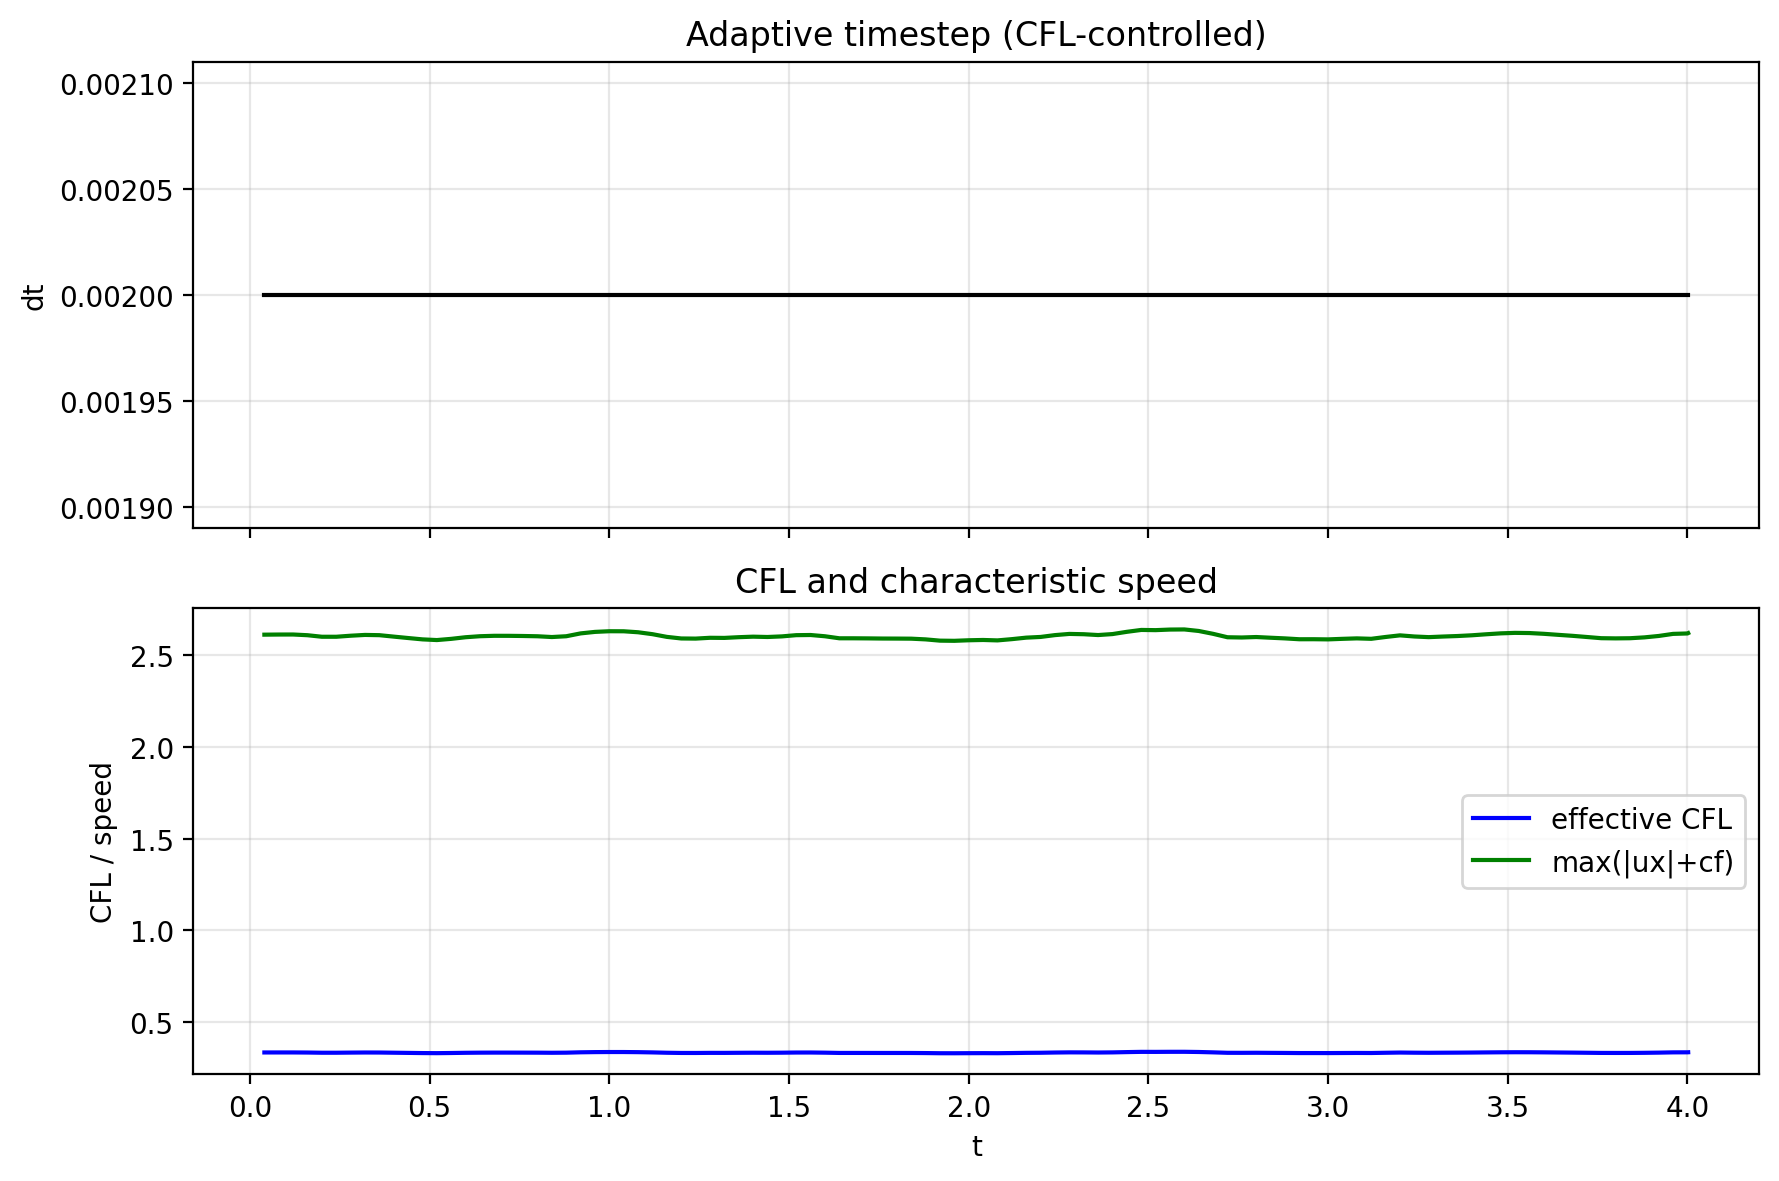

In [8]:
# Time-step diagnostics only (CFL-focused)
if 't_diag' not in globals() or len(t_diag) == 0:
    print("No timestep diagnostics found. Run Cell 9 first.")
else:
    print("CFL summary")
    print(f"  steps recorded: {len(t_diag)}")
    print(f"  final time: {t_diag[-1]:.5f}")
    print(f"  dt range: [{np.min(dt_diag):.2e}, {np.max(dt_diag):.2e}]")
    print(f"  CFL range: [{np.min(cfl_diag):.3f}, {np.max(cfl_diag):.3f}]")
    print(f"  max speed range: [{np.min(maxspeed_diag):.3f}, {np.max(maxspeed_diag):.3f}]")

    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    axes[0].plot(t_diag, dt_diag, 'k-')
    axes[0].set_ylabel('dt')
    axes[0].set_title('Adaptive timestep (CFL-controlled)')
    axes[0].grid(alpha=0.3)

    axes[1].plot(t_diag, cfl_diag, 'b-', label='effective CFL')
    axes[1].plot(t_diag, maxspeed_diag, 'g-', label='max(|ux|+cf)')
    axes[1].set_xlabel('t')
    axes[1].set_ylabel('CFL / speed')
    axes[1].set_title('CFL and characteristic speed')
    axes[1].legend(loc='best')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Space-time fields, energy tracking, and pressure comparison

This cell reads HDF5 outputs and provides:
- expanded space-time evolution panels for additional fields,
- total energy vs time,
- comparison of adiabatic pressure $p_{\mathrm{adi}}=\rho^\gamma$ with pressure from conservative variables (and saved pressure task).

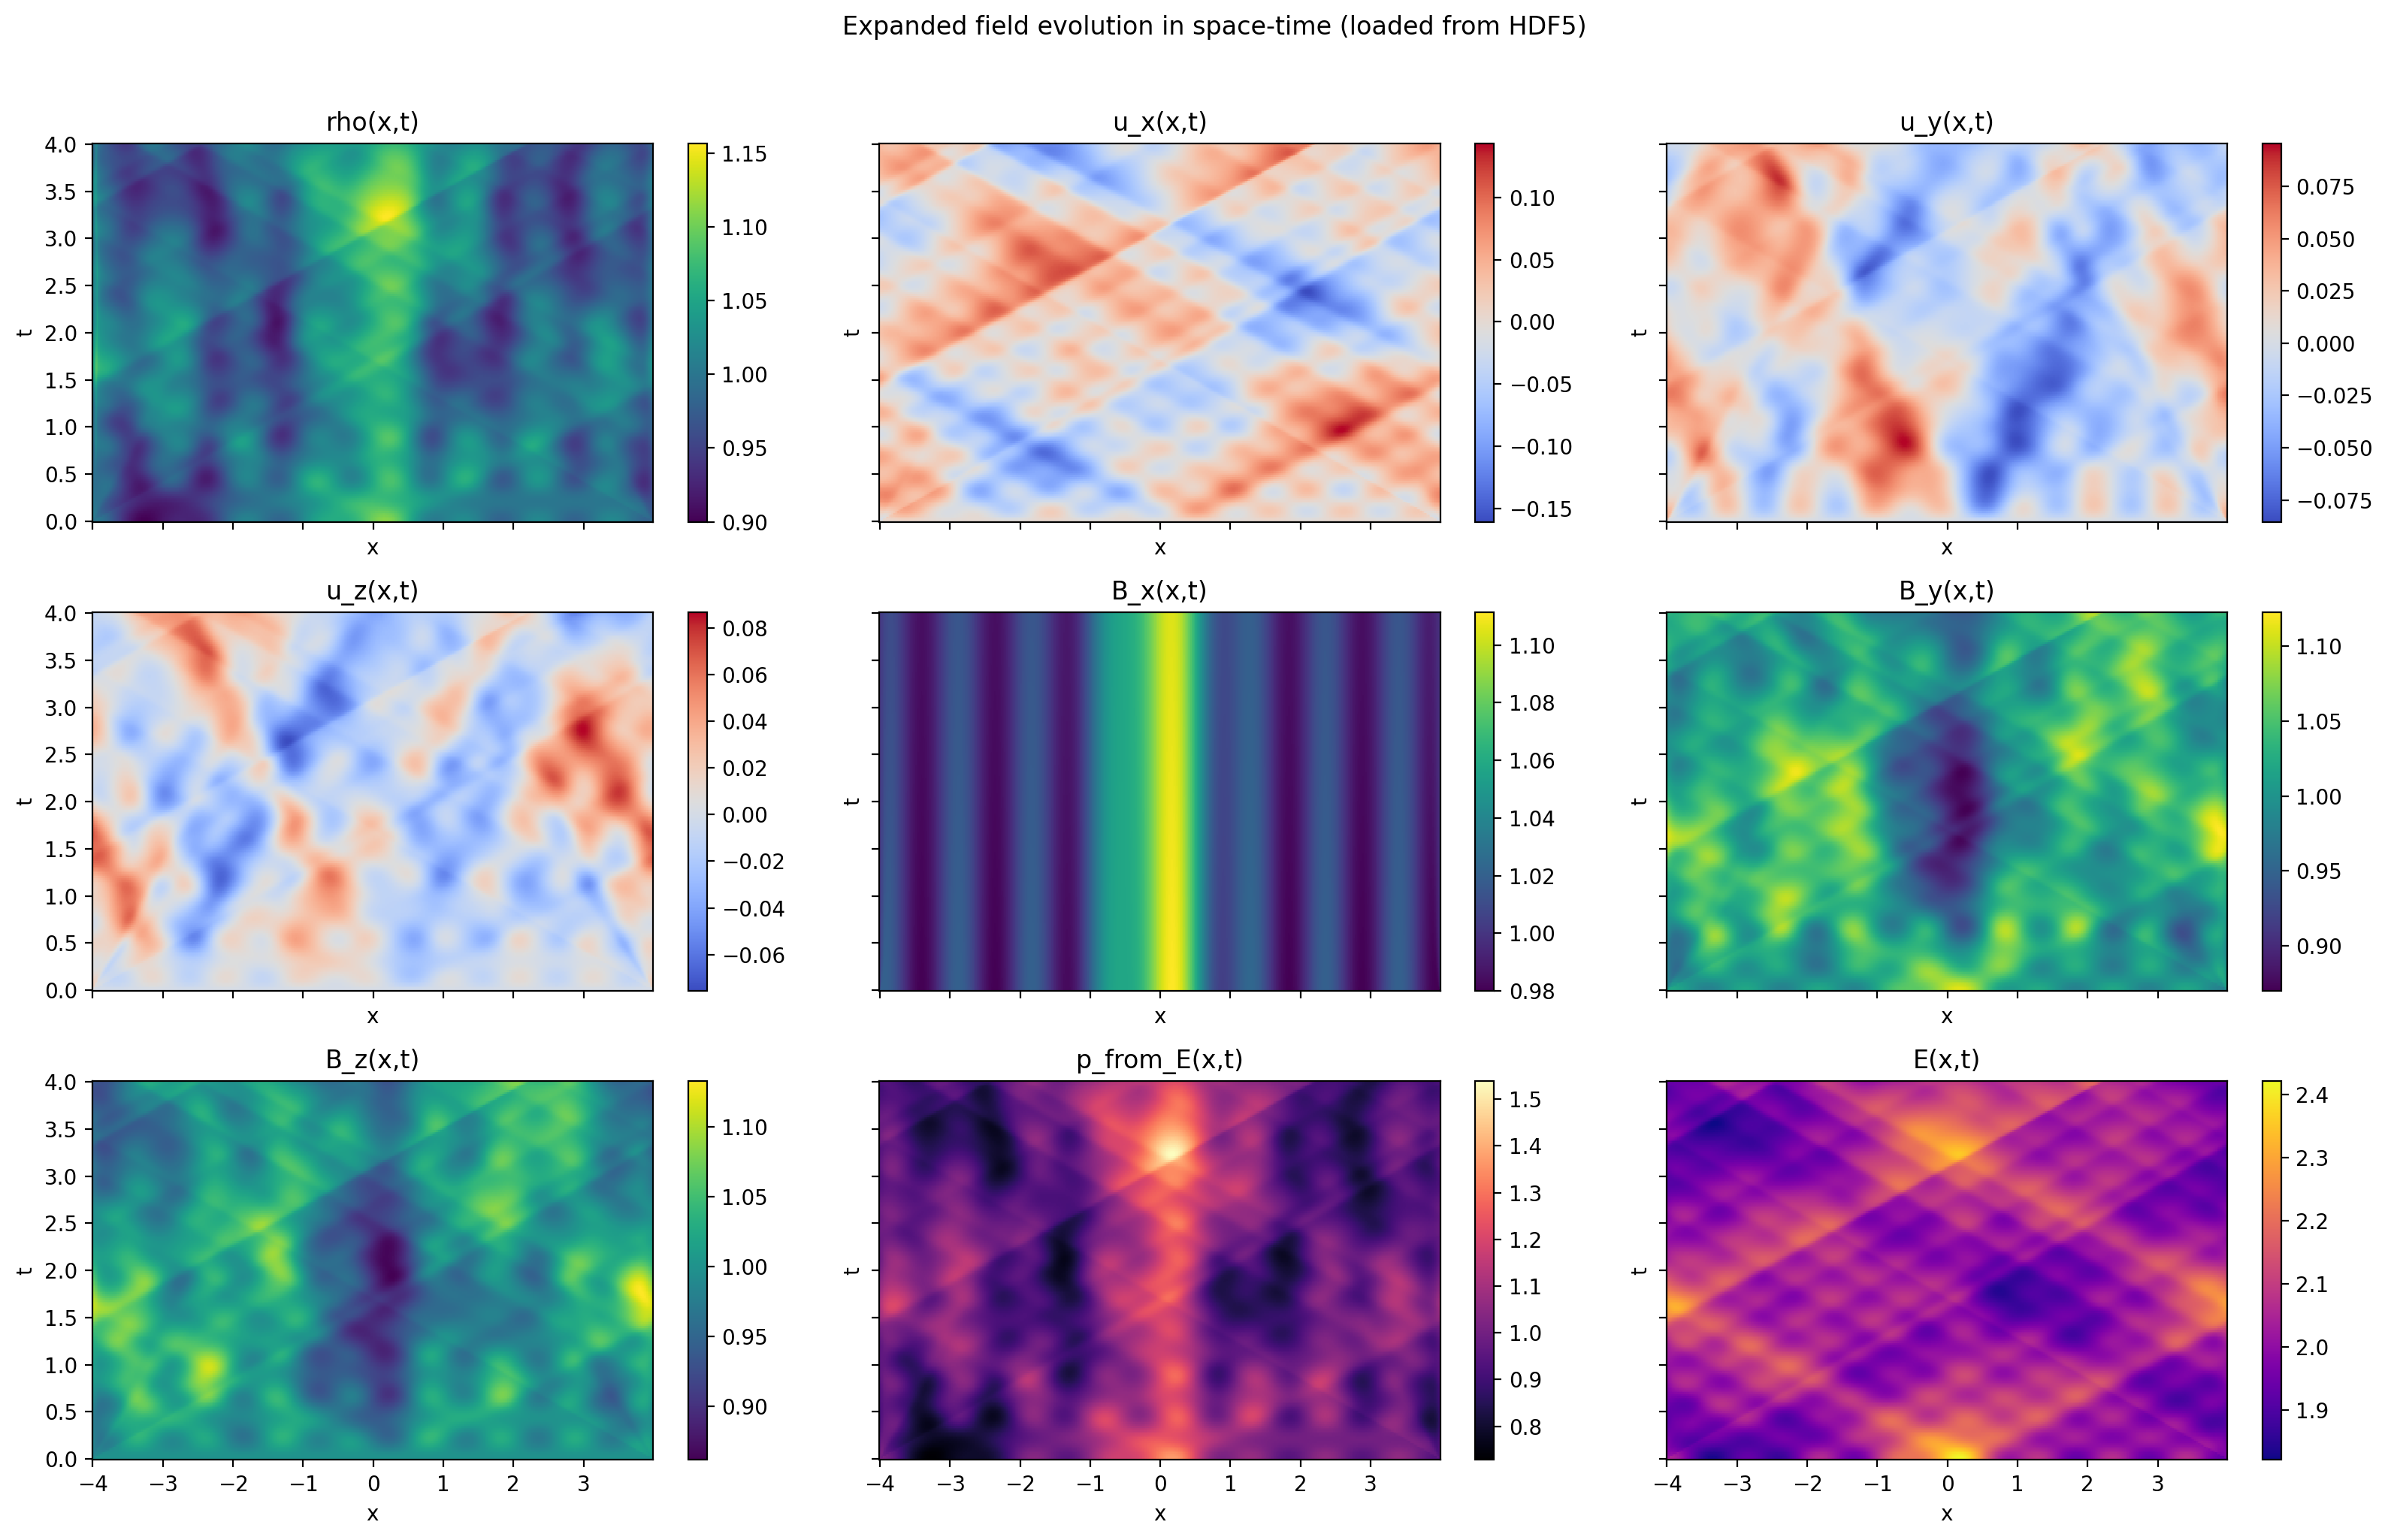

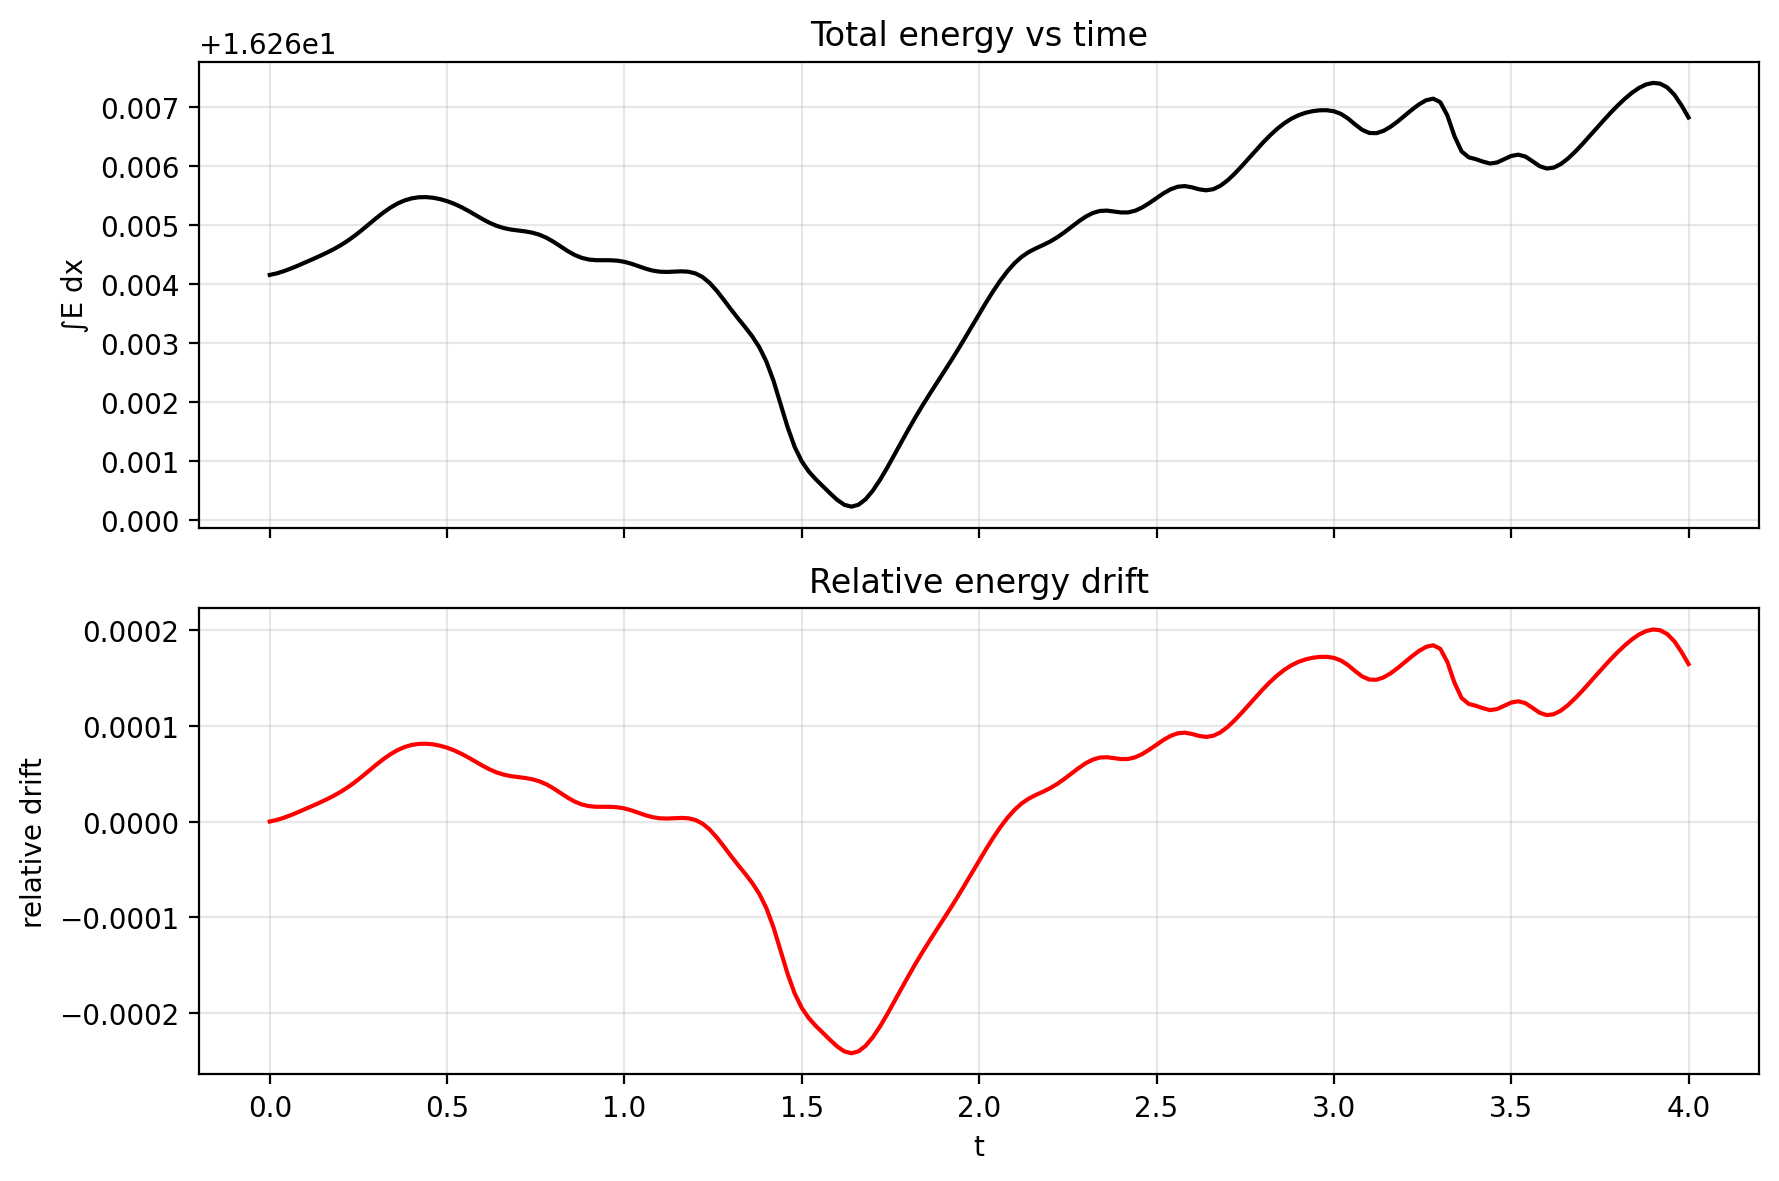

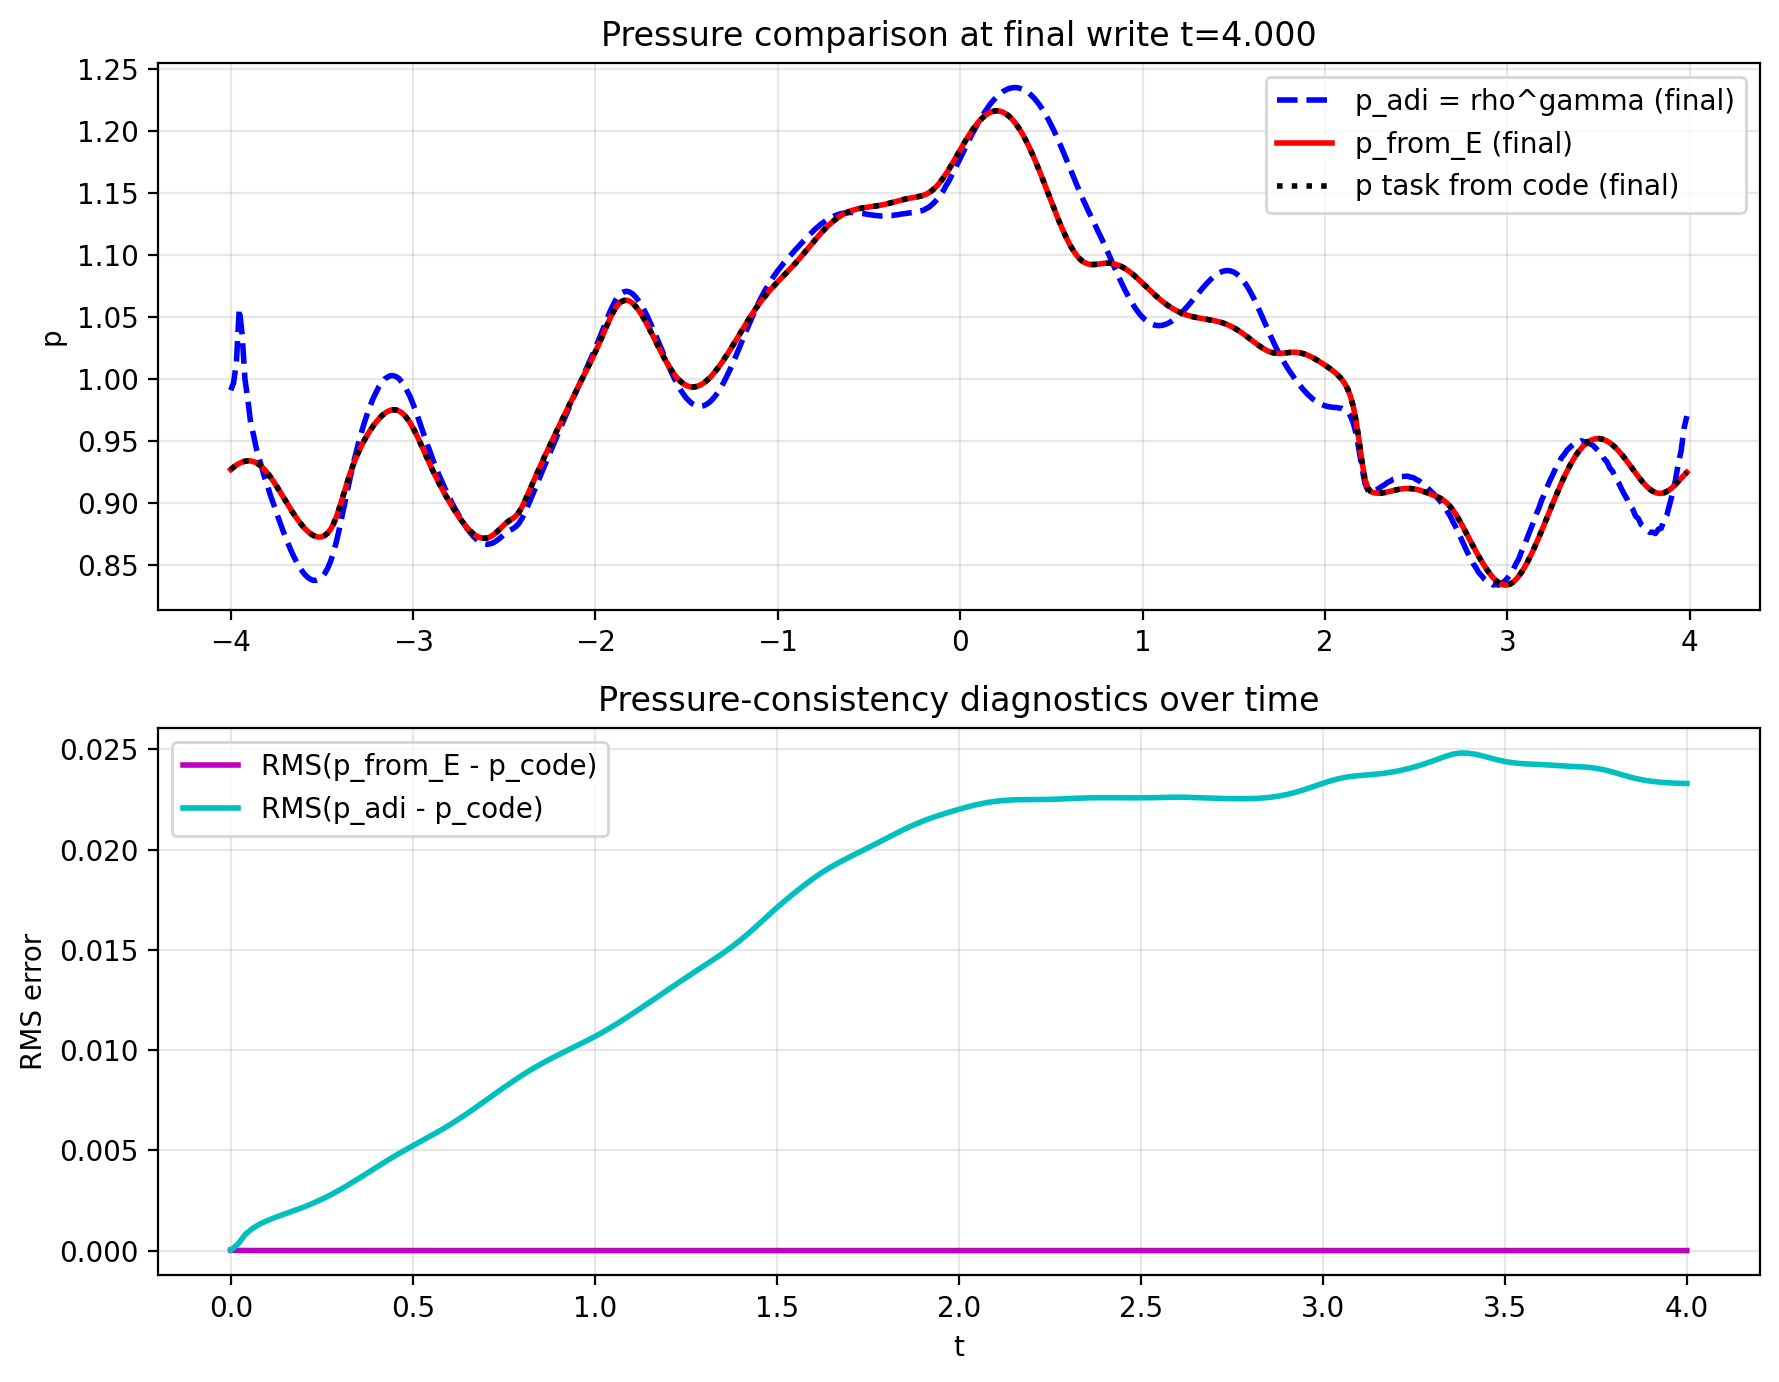

In [9]:
# Expanded HDF5 diagnostics: more fields in x-t, total energy, pressure consistency
analysis_dir = Path('analysis_mhd')
analysis_files = sorted(analysis_dir.glob('analysis_mhd_s*.h5'))

if len(analysis_files) == 0:
    print("No analysis HDF5 files found. Run Cell 9 first.")
else:
    def load_task_from_sets(task_name):
        t_list = []
        a_list = []
        x_vals = None

        for fp in analysis_files:
            with h5py.File(fp, mode='r') as f:
                ds = f['tasks'][task_name]
                data = np.asarray(ds)
                sim_t = np.asarray(ds.dims[0]['sim_time'])
                if data.ndim >= 2 and x_vals is None:
                    x_vals = np.asarray(ds.dims[1][0])

            t_list.append(sim_t)
            a_list.append(data)

        t_all = np.concatenate(t_list, axis=0)
        a_all = np.concatenate(a_list, axis=0)
        return np.real(t_all), np.real(a_all), np.real(x_vals)

    # Load base tasks from HDF5
    t_rho, rho_arr, x_plot = load_task_from_sets('rho')
    t_mx, mx_arr, _ = load_task_from_sets('mx')
    t_my, my_arr, _ = load_task_from_sets('my')
    t_mz, mz_arr, _ = load_task_from_sets('mz')
    t_bx, bx_arr, _ = load_task_from_sets('Bx')
    t_by, by_arr, _ = load_task_from_sets('By')
    t_bz, bz_arr, _ = load_task_from_sets('Bz')
    t_E, E_arr, _ = load_task_from_sets('E')
    t_p, p_code_arr, _ = load_task_from_sets('p')

    n_common = min(
        len(t_rho), len(t_mx), len(t_my), len(t_mz),
        len(t_bx), len(t_by), len(t_bz), len(t_E), len(t_p)
    )

    t_plot = t_rho[:n_common]
    rho_arr = np.maximum(rho_arr[:n_common], 1e-12)
    mx_arr = mx_arr[:n_common]
    my_arr = my_arr[:n_common]
    mz_arr = mz_arr[:n_common]
    bx_arr = bx_arr[:n_common]
    by_arr = by_arr[:n_common]
    bz_arr = bz_arr[:n_common]
    E_arr = E_arr[:n_common]
    p_code_arr = p_code_arr[:n_common]

    ux_arr = mx_arr / rho_arr
    uy_arr = my_arr / rho_arr
    uz_arr = mz_arr / rho_arr

    # Pressure from conservative variables (as in shocktube-style check)
    p_from_E_arr = (gamma - 1) * (
        E_arr
        - 0.5 * rho_arr * (ux_arr**2 + uy_arr**2 + uz_arr**2)
        - 0.5 * (bx_arr**2 + by_arr**2 + bz_arr**2)
    )
    p_adi_arr = rho_arr**gamma

    p_from_E_arr = np.nan_to_num(p_from_E_arr, nan=0.0, posinf=0.0, neginf=0.0)
    p_adi_arr = np.nan_to_num(p_adi_arr, nan=0.0, posinf=0.0, neginf=0.0)
    p_code_arr = np.nan_to_num(p_code_arr, nan=0.0, posinf=0.0, neginf=0.0)

    TT, XX = np.meshgrid(t_plot, x_plot, indexing='ij')

    # 1) Expanded space-time figure (3x3)
    fields = [
        ('rho(x,t)', rho_arr, 'viridis'),
        ('u_x(x,t)', ux_arr, 'coolwarm'),
        ('u_y(x,t)', uy_arr, 'coolwarm'),
        ('u_z(x,t)', uz_arr, 'coolwarm'),
        ('B_x(x,t)', bx_arr, 'viridis'),
        ('B_y(x,t)', by_arr, 'viridis'),
        ('B_z(x,t)', bz_arr, 'viridis'),
        ('p_from_E(x,t)', p_from_E_arr, 'magma'),
        ('E(x,t)', E_arr, 'plasma'),
    ]

    fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True, sharey=True)
    axes_list = list(axes.flat)

    for ax, (title, arr, cmap) in zip(axes_list, fields):
        pcm = ax.pcolormesh(XX, TT, arr, shading='auto', cmap=cmap)
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_ylabel('t')
        fig.colorbar(pcm, ax=ax)

    plt.suptitle('Expanded field evolution in space-time (loaded from HDF5)', y=1.02)
    plt.tight_layout()
    plt.show()

    # 2) Total energy tracking
    total_energy = np.trapezoid(E_arr, x_plot, axis=1)
    rel_energy = (total_energy - total_energy[0]) / max(abs(total_energy[0]), 1e-14)

    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    axes[0].plot(t_plot, total_energy, 'k-')
    axes[0].set_ylabel('∫E dx')
    axes[0].set_title('Total energy vs time')
    axes[0].grid(alpha=0.3)

    axes[1].plot(t_plot, rel_energy, 'r-')
    axes[1].set_xlabel('t')
    axes[1].set_ylabel('relative drift')
    axes[1].set_title('Relative energy drift')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 3) Pressure comparison (adiabatic vs from-E vs saved p task)
    p_err_code = np.sqrt(np.mean((p_from_E_arr - p_code_arr)**2, axis=1))
    p_err_adi = np.sqrt(np.mean((p_adi_arr - p_code_arr)**2, axis=1))

    fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=False)
    axes[0].plot(x_plot, p_adi_arr[-1], 'b--', lw=2, label='p_adi = rho^gamma (final)')
    axes[0].plot(x_plot, p_from_E_arr[-1], 'r-', lw=2, label='p_from_E (final)')
    axes[0].plot(x_plot, p_code_arr[-1], 'k:', lw=2, label='p task from code (final)')
    axes[0].set_ylabel('p')
    axes[0].set_title(f'Pressure comparison at final write t={t_plot[-1]:.3f}')
    axes[0].grid(alpha=0.3)
    axes[0].legend(loc='best')

    axes[1].plot(t_plot, p_err_code, 'm-', lw=2, label='RMS(p_from_E - p_code)')
    axes[1].plot(t_plot, p_err_adi, 'c-', lw=2, label='RMS(p_adi - p_code)')
    axes[1].set_xlabel('t')
    axes[1].set_ylabel('RMS error')
    axes[1].set_title('Pressure-consistency diagnostics over time')
    axes[1].grid(alpha=0.3)
    axes[1].legend(loc='best')

    plt.tight_layout()
    plt.show()

## Pressure-density, ML closure, and dispersion diagnostics

This section mirrors the `shocktube.ipynb` post-processing style:
- pressure vs density scatter,
- MLP training for pressure prediction from $(\rho, u_x, u_y, u_z, B_x, B_y, B_z)$,
- prediction-quality plots,
- Jacobian/eigenvalue-based dispersion diagnostics from the learned closure.

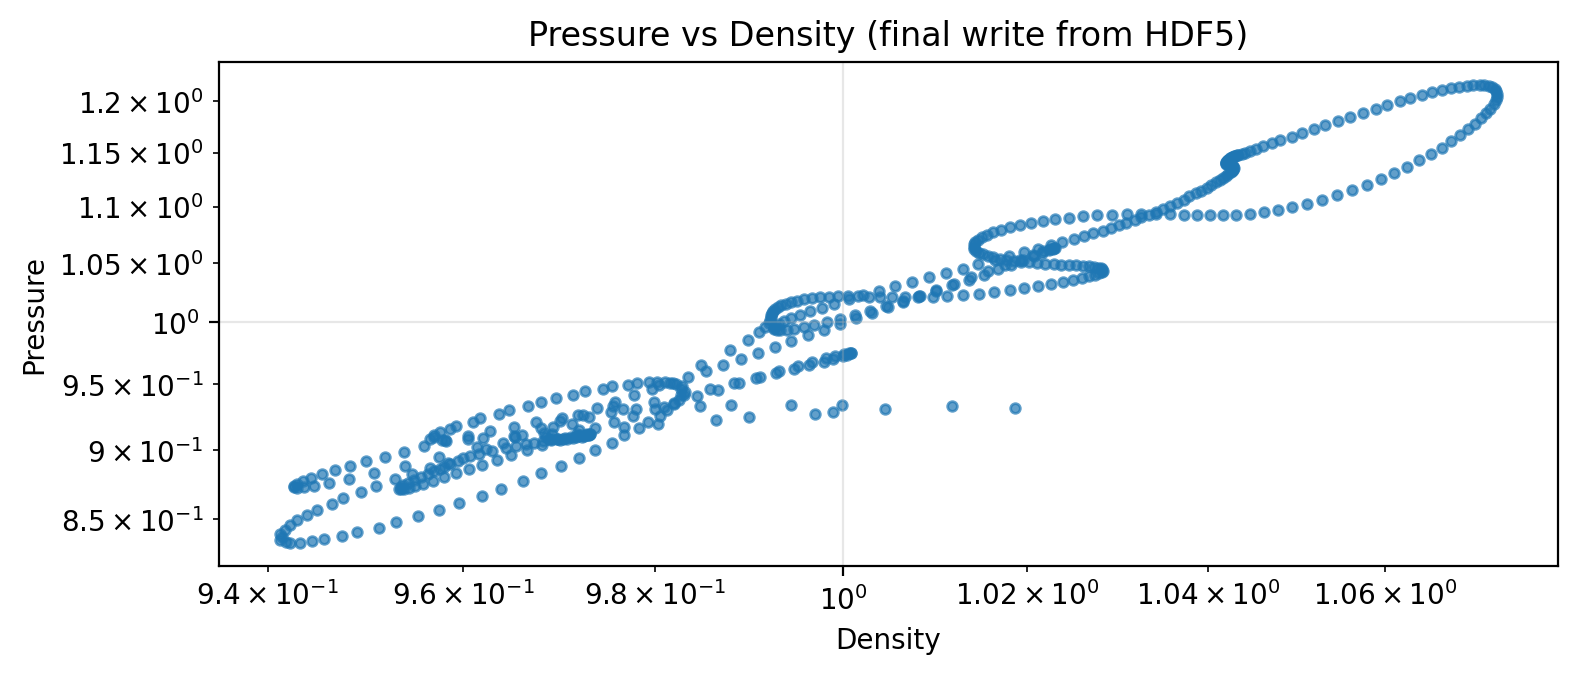

In [10]:
# Pressure vs density scatter (from final HDF5 write)
analysis_dir = Path('analysis_mhd')
analysis_files = sorted(analysis_dir.glob('analysis_mhd_s*.h5'))

if len(analysis_files) == 0:
    print("No analysis HDF5 files found. Run Cell 9 first.")
else:
    with h5py.File(analysis_files[-1], mode='r') as f:
        rho_plot = np.real(np.asarray(f['tasks']['rho'][-1]))
        p_plot = np.real(np.asarray(f['tasks']['p'][-1]))

    rho_plot = np.maximum(np.nan_to_num(rho_plot, nan=1e-12, posinf=1e-12, neginf=1e-12), 1e-12)
    p_plot = np.maximum(np.nan_to_num(p_plot, nan=1e-12, posinf=1e-12, neginf=1e-12), 1e-12)

    plt.figure(figsize=(8, 3.5))
    plt.scatter(rho_plot, p_plot, s=12, alpha=0.7)
    plt.xlabel('Density')
    plt.ylabel('Pressure')
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Pressure vs Density (final write from HDF5)')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Network choice and regularization rationale

The pressure closure is modeled with a compact **MLP** that maps  
$$
(\rho, u_x, u_y, u_z, B_x, B_y, B_z)\ \rightarrow\ p.
$$

### Why this network?
- **Fully connected MLP** is appropriate because each sample is a local state vector (no spatial stencil required).
- **Three hidden layers (32 units each)** provide enough nonlinearity for MHD thermodynamic coupling without becoming overly large.
- **`tanh` activations** are smooth and bounded, which helps represent continuous constitutive behavior and keeps Jacobian-based analyses more stable than piecewise-linear activations.
- **Small model size** improves robustness and reduces overfitting risk for moderate dataset size.

### Why normalization?
- Inputs and target pressure are standardized using **training-split statistics only**.
- This keeps features on comparable scales, improves optimizer conditioning, and prevents data leakage from test times.

### Regularization and stability controls
- **Dropout (0.10):** discourages feature co-adaptation and improves generalization.
- **AdamW with weight decay (`1e-4`):** penalizes overly large weights and smooths the learned mapping.
- **One-cycle cosine learning-rate schedule:** fast early progress with controlled late-stage refinement.
- **Gradient clipping (`max_norm=1.0`):** prevents unstable updates from rare large gradients.
- **Early stopping (patience-based):** halts training when test loss no longer improves, limiting overfitting.

### Time-aware validation design
- Train/test split is **chronological** (first 80% of writes for training, final 20% for testing), matching forecasting-style deployment and providing a stricter generalization test than random shuffling.

In [11]:
# ML training with TIME-ORDERED split + normalization
# Train on first 80% of time writes, test on final 20%

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

analysis_dir = Path('analysis_mhd')
analysis_files = sorted(analysis_dir.glob('analysis_mhd_s*.h5'))
if len(analysis_files) == 0:
    print("No analysis HDF5 files found. Run Cell 9 first.")
else:
    def load_task_from_sets(task_name):
        t_list = []
        a_list = []
        for fp in analysis_files:
            with h5py.File(fp, mode='r') as f:
                ds = f['tasks'][task_name]
                a_list.append(np.real(np.asarray(ds)))
                t_list.append(np.asarray(ds.dims[0]['sim_time']))
        t_all = np.concatenate(t_list, axis=0)
        a_all = np.concatenate(a_list, axis=0)
        return np.real(t_all), np.real(a_all)

    # Load full time history
    t_all, rho_all = load_task_from_sets('rho')
    _, mx_all = load_task_from_sets('mx')
    _, my_all = load_task_from_sets('my')
    _, mz_all = load_task_from_sets('mz')
    _, bx_all = load_task_from_sets('Bx')
    _, by_all = load_task_from_sets('By')
    _, bz_all = load_task_from_sets('Bz')
    _, p_all = load_task_from_sets('p')

    # Build primitive features
    rho_safe = np.maximum(rho_all, 1e-12)
    ux_all = mx_all / rho_safe
    uy_all = my_all / rho_safe
    uz_all = mz_all / rho_safe

    X_all = np.stack([rho_safe, ux_all, uy_all, uz_all, bx_all, by_all, bz_all], axis=-1)  # [Nt, Nx, 7]
    y_all = p_all[..., None]  # [Nt, Nx, 1]

    # Chronological split in time: first 80% train, final 20% test
    n_time = X_all.shape[0]
    n_train_time = max(1, int(0.8 * n_time))
    n_train_time = min(n_train_time, n_time - 1) if n_time > 1 else 1

    X_train_raw = X_all[:n_train_time].reshape(-1, 7)
    y_train_raw = y_all[:n_train_time].reshape(-1, 1)
    X_test_raw = X_all[n_train_time:].reshape(-1, 7)
    y_test_raw = y_all[n_train_time:].reshape(-1, 1)

    # Normalization stats from TRAIN split only
    eps = 1e-12
    x_mean = X_train_raw.mean(axis=0, keepdims=True)
    x_std = X_train_raw.std(axis=0, keepdims=True) + eps
    y_mean = y_train_raw.mean(axis=0, keepdims=True)
    y_std = y_train_raw.std(axis=0, keepdims=True) + eps

    X_train_norm = (X_train_raw - x_mean) / x_std
    y_train_norm = (y_train_raw - y_mean) / y_std
    X_test_norm = (X_test_raw - x_mean) / x_std
    y_test_norm = (y_test_raw - y_mean) / y_std

    # Torch tensors
    X_train = torch.tensor(X_train_norm, dtype=torch.float32)
    y_train = torch.tensor(y_train_norm, dtype=torch.float32)
    X_test = torch.tensor(X_test_norm, dtype=torch.float32)
    y_test = torch.tensor(y_test_norm, dtype=torch.float32)

    train_ds = TensorDataset(X_train, y_train)
    test_ds = TensorDataset(X_test, y_test)

    train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
    test_dl = DataLoader(test_ds, batch_size=256, shuffle=False)

    class MLP(nn.Module):
        def __init__(self, dropout=0.10):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(7, 32),
                nn.Tanh(),
                nn.Dropout(dropout),
                nn.Linear(32, 32),
                nn.Tanh(),
                nn.Dropout(dropout),
                nn.Linear(32, 32),
                nn.Tanh(),
                nn.Dropout(dropout),
                nn.Linear(32, 1),
            )

        def forward(self, x):
            return self.net(x)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = MLP(dropout=0.10).to(device)

    # Regularized optimizer + schedule
    base_lr = 1e-3
    weight_decay = 1e-4
    optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    # Early stopping setup
    max_epochs = 3000
    patience = 250
    min_delta = 1e-5

    # One-cycle cosine LR schedule (batch-wise)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=base_lr,
        epochs=max_epochs,
        steps_per_epoch=max(1, len(train_dl)),
        pct_start=0.2,
        anneal_strategy='cos',
        div_factor=10.0,
        final_div_factor=100.0,
    )

    def run_epoch(dataloader, train=False):
        model.train(train)
        total_loss = 0.0
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
            total_loss += loss.item() * len(xb)
        return total_loss / len(dataloader.dataset)

    train_losses = []
    test_losses = []
    lr_history = []

    best_test_loss = np.inf
    best_epoch = 0
    epochs_no_improve = 0
    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    for epoch in range(1, max_epochs + 1):
        train_loss = run_epoch(train_dl, train=True)
        test_loss = run_epoch(test_dl, train=False)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        lr_now = float(optimizer.param_groups[0]['lr'])
        lr_history.append(lr_now)

        if test_loss < best_test_loss - min_delta:
            best_test_loss = test_loss
            best_epoch = epoch
            epochs_no_improve = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1

        if epoch % 100 == 0 or epoch == 1:
            print(
                f"epoch {epoch:4d} | lr {lr_now:.2e} | train {train_loss:.4f} | "
                f"test {test_loss:.4f} | best_test {best_test_loss:.4f} (epoch {best_epoch})"
            )

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (no test improvement for {patience} epochs).")
            break

    # Restore best model (by test loss)
    model.load_state_dict(best_state)

    # Save model + normalization for later cells
    ml_model = model
    ml_device = device

    ml_x_mean_np = x_mean.astype(np.float32)
    ml_x_std_np = x_std.astype(np.float32)
    ml_y_mean_np = y_mean.astype(np.float32)
    ml_y_std_np = y_std.astype(np.float32)

    ml_x_mean_t = torch.tensor(ml_x_mean_np, dtype=torch.float32, device=ml_device)
    ml_x_std_t = torch.tensor(ml_x_std_np, dtype=torch.float32, device=ml_device)
    ml_y_mean_t = torch.tensor(ml_y_mean_np, dtype=torch.float32, device=ml_device)
    ml_y_std_t = torch.tensor(ml_y_std_np, dtype=torch.float32, device=ml_device)

    ml_train_losses = train_losses
    ml_test_losses = test_losses
    ml_lr_history = lr_history
    ml_best_test_loss = float(best_test_loss)
    ml_best_epoch = int(best_epoch)
    ml_time_split_index = n_train_time
    ml_time_train = t_all[:n_train_time]
    ml_time_test = t_all[n_train_time:]

    # Keep raw (unnormalized) test data for evaluation/plots
    ml_X_test_raw = X_test_raw.astype(np.float32)
    ml_y_test_raw = y_test_raw.astype(np.float32)

    def ml_predict_pressure_np(X_raw_np):
        X_raw_np = np.asarray(X_raw_np, dtype=np.float32)
        X_norm_np = (X_raw_np - ml_x_mean_np) / ml_x_std_np
        with torch.no_grad():
            X_t = torch.tensor(X_norm_np, dtype=torch.float32, device=ml_device)
            y_norm_pred = ml_model.float().to(ml_device)(X_t).cpu().numpy()
        y_pred = y_norm_pred * ml_y_std_np + ml_y_mean_np
        return y_pred.reshape(-1)

    print("\nTraining done with chronological split:")
    print(f"  total time writes: {n_time}")
    print(f"  train writes (first 80%): {n_train_time}")
    print(f"  test writes (final 20%): {n_time - n_train_time}")
    print(f"  train samples: {len(X_train_raw)}")
    print(f"  test samples: {len(X_test_raw)}")
    print(f"  best test loss: {best_test_loss:.6f} at epoch {best_epoch}")

epoch    1 | lr 1.00e-04 | train 0.3187 | test 0.1223 | best_test 0.1223 (epoch 1)
epoch  100 | lr 1.60e-04 | train 0.0291 | test 0.0441 | best_test 0.0441 (epoch 100)
epoch  200 | lr 3.25e-04 | train 0.0277 | test 0.0416 | best_test 0.0405 (epoch 193)
epoch  300 | lr 5.50e-04 | train 0.0275 | test 0.0415 | best_test 0.0402 (epoch 272)
epoch  400 | lr 7.75e-04 | train 0.0276 | test 0.0435 | best_test 0.0401 (epoch 321)
epoch  500 | lr 9.40e-04 | train 0.0280 | test 0.0435 | best_test 0.0401 (epoch 321)
Early stopping at epoch 571 (no test improvement for 250 epochs).

Training done with chronological split:
  total time writes: 201
  train writes (first 80%): 160
  test writes (final 20%): 41
  train samples: 81920
  test samples: 20992
  best test loss: 0.040139 at epoch 321


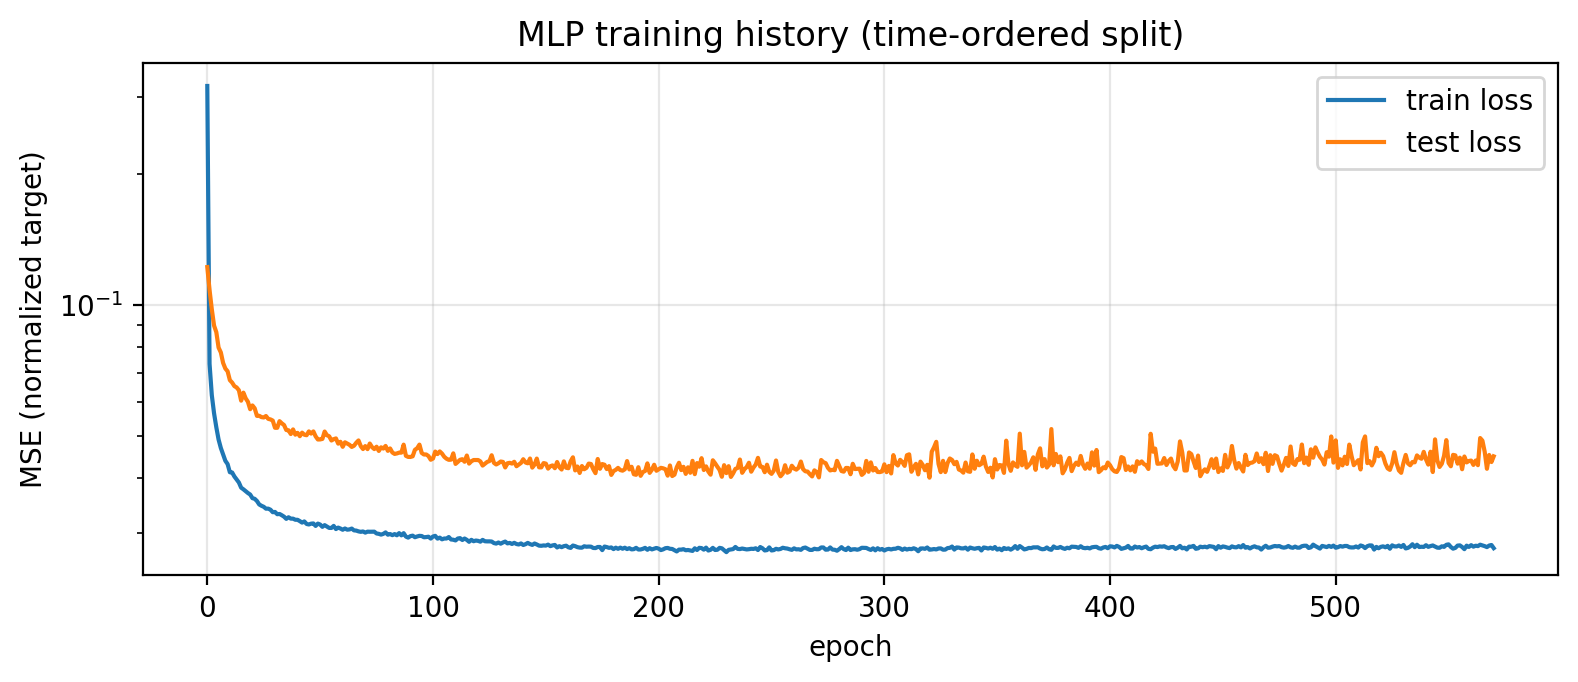

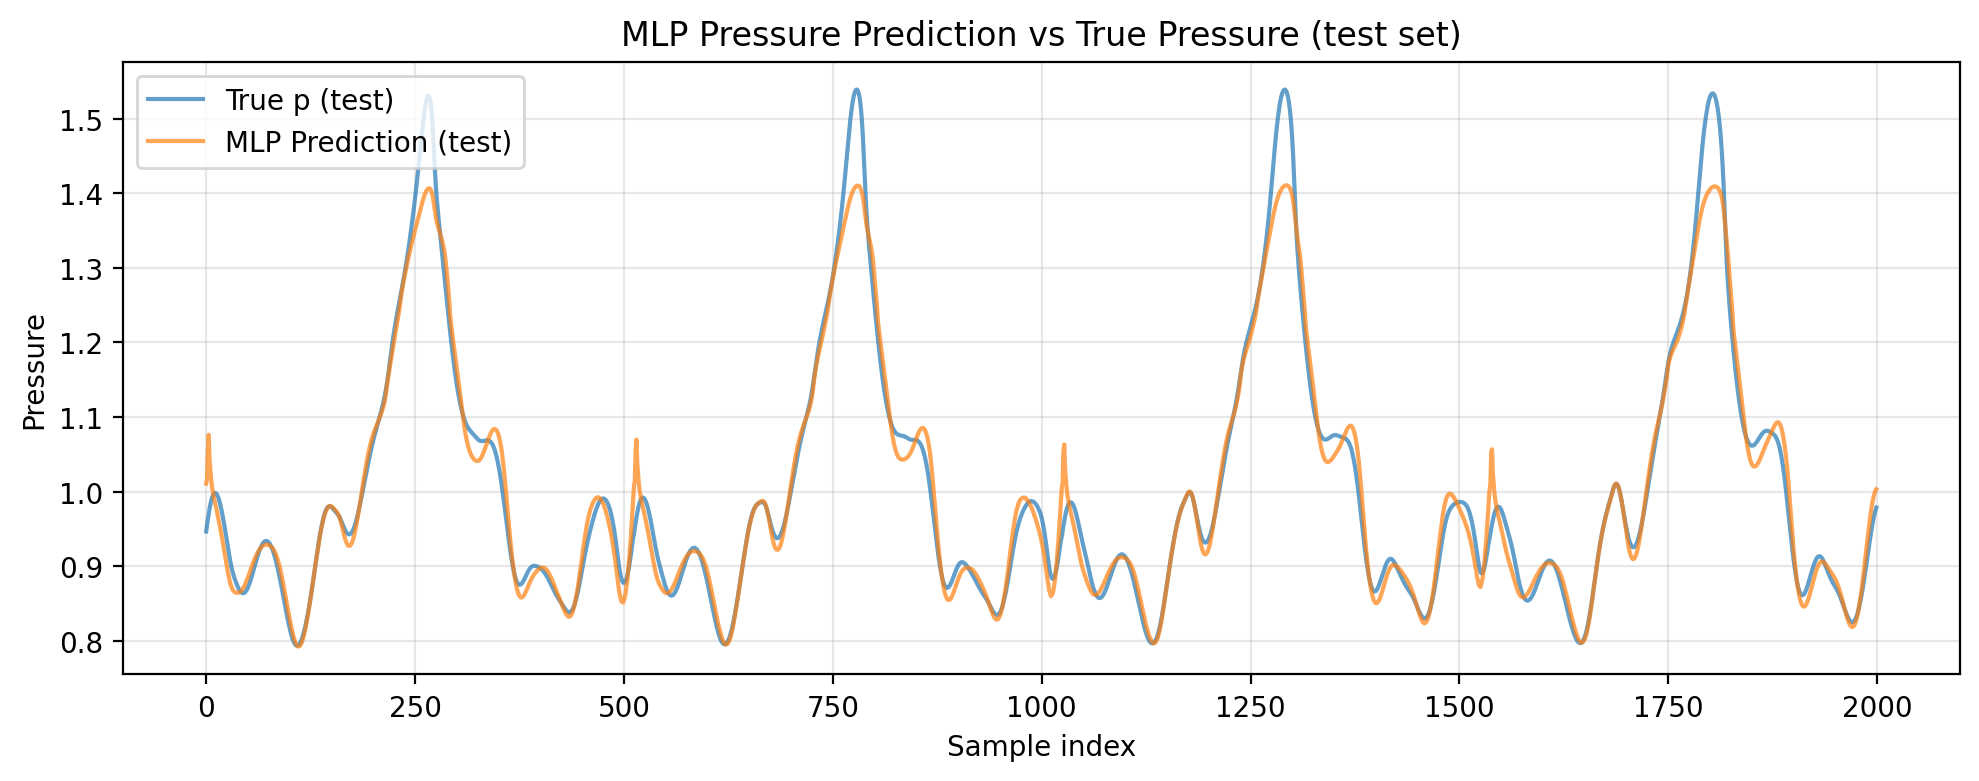

Test RMSE: 2.274730e-02
Test R²: 0.977009


In [15]:
# Prediction diagnostics with normalization-aware inference
if 'ml_model' not in globals() or 'ml_X_test_raw' not in globals():
    print("ML model/test data not found. Run Cell 20 first.")
else:
    # Learning curve (normalized MSE)
    plt.figure(figsize=(8, 3.5))
    plt.plot(ml_train_losses, label='train loss')
    plt.plot(ml_test_losses, label='test loss')
    plt.yscale('log')
    plt.xlabel('epoch')
    plt.ylabel('MSE (normalized target)')
    plt.title('MLP training history (time-ordered split)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Denormalized prediction vs truth on test set
    p_pred_all = ml_predict_pressure_np(ml_X_test_raw)
    p_true_all = ml_y_test_raw.reshape(-1)

    plt.figure(figsize=(10, 4))
    sample_size = min(2000, len(p_true_all))
    plt.plot(p_true_all[:sample_size], label='True p (test)', alpha=0.7)
    plt.plot(p_pred_all[:sample_size], label='MLP Prediction (test)', alpha=0.7)
    plt.xlabel('Sample index')
    plt.ylabel('Pressure')
    plt.title('MLP Pressure Prediction vs True Pressure (test set)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Test RMSE: {np.sqrt(np.mean((p_pred_all - p_true_all)**2)):.6e}")
    print(f"Test R²: {1 - np.sum((p_pred_all - p_true_all)**2) / np.sum((p_true_all - p_true_all.mean())**2):.6f}")

Plot for rho vs ux, -0.1221 < ux < 0.1099
Plot for rho vs uy, -0.0702 < uy < 0.0891
Plot for rho vs uz, -0.0669 < uz < 0.0716
Plot for rho vs Bx, 0.9841 < Bx < 1.1059
Plot for rho vs By, 0.9378 < By < 1.1017
Plot for rho vs Bz, 0.9245 < Bz < 1.0808


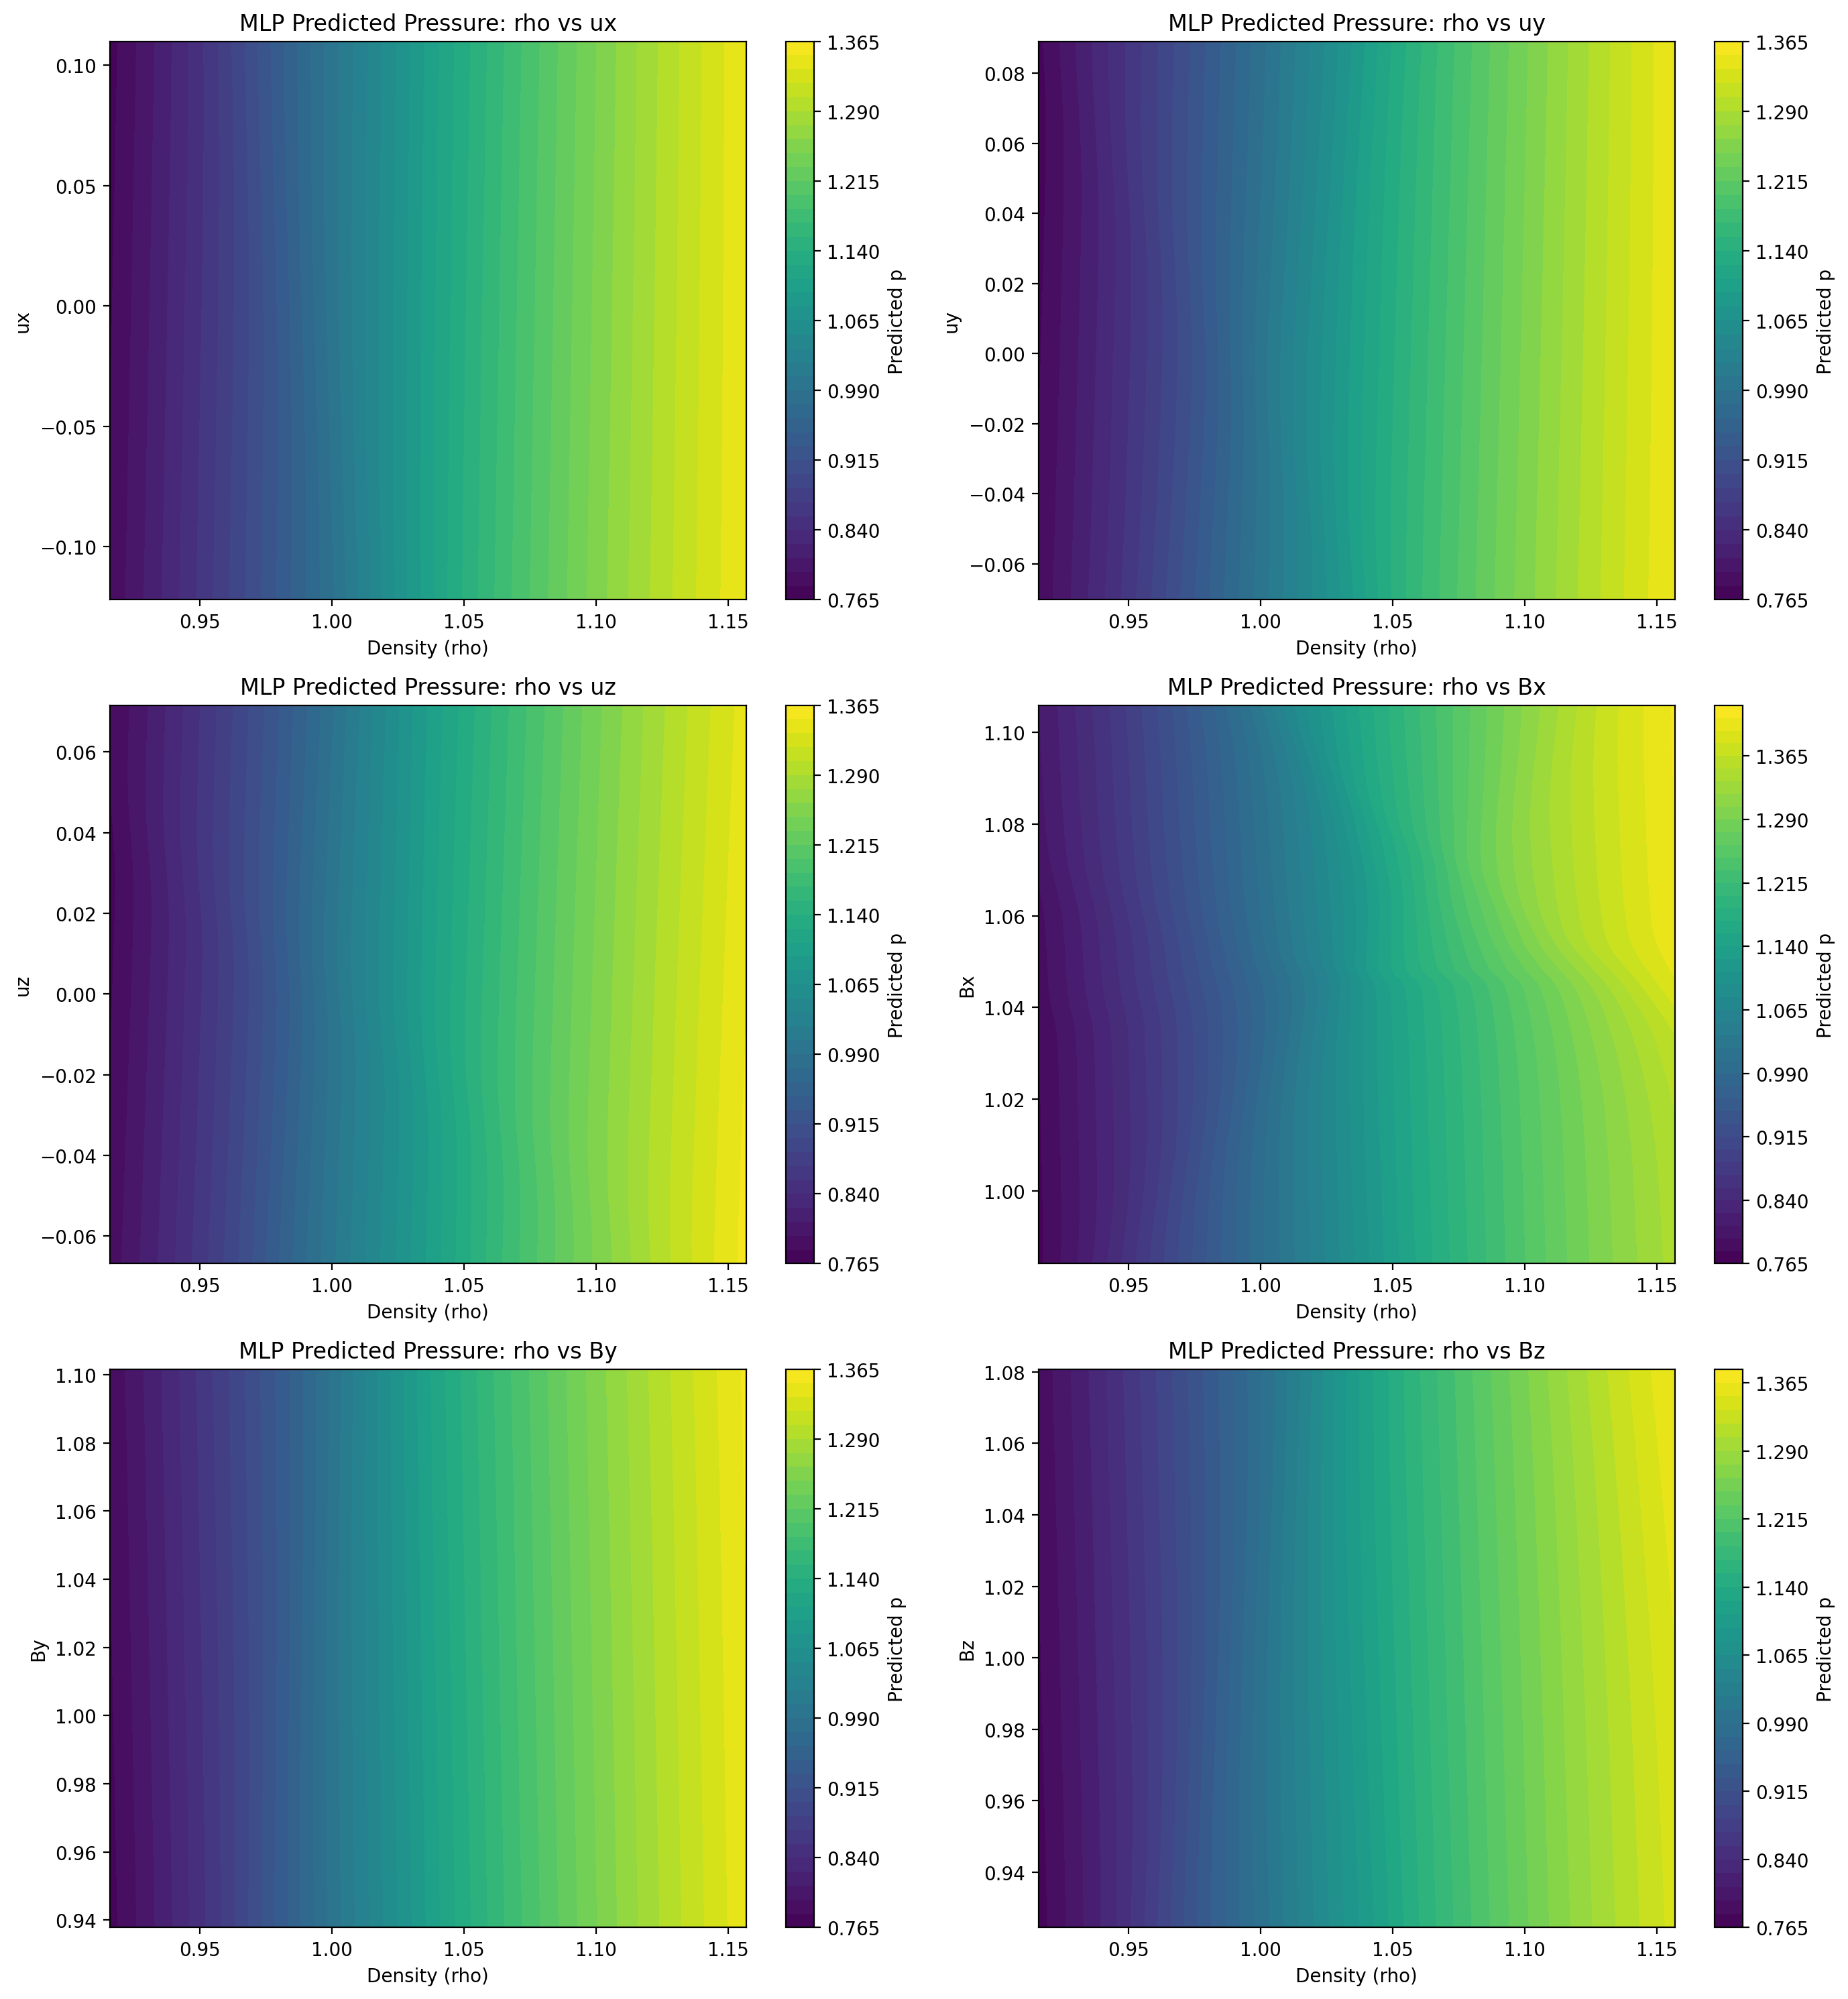

In [16]:
# Feature sensitivity contour plots (rho vs each feature, normalization-aware)
if 'ml_model' not in globals() or 'ml_X_test_raw' not in globals():
    print("ML model/test data not found. Run Cell 20 first.")
else:
    model_inference = ml_model.float().to(ml_device)
    model_inference.eval()

    # Use test data ranges
    rho_orig = ml_X_test_raw[:, 0]
    ux_orig = ml_X_test_raw[:, 1]
    uy_orig = ml_X_test_raw[:, 2]
    uz_orig = ml_X_test_raw[:, 3]
    bx_orig = ml_X_test_raw[:, 4]
    by_orig = ml_X_test_raw[:, 5]
    bz_orig = ml_X_test_raw[:, 6]

    rho_space = np.linspace(rho_orig.min(), rho_orig.max(), 100)

    features = ['ux', 'uy', 'uz', 'Bx', 'By', 'Bz']
    feature_arrays = [ux_orig, uy_orig, uz_orig, bx_orig, by_orig, bz_orig]
    feature_indices = [1, 2, 3, 4, 5, 6]

    mean_values = [
        rho_orig.mean(),
        ux_orig.mean(),
        uy_orig.mean(),
        uz_orig.mean(),
        bx_orig.mean(),
        by_orig.mean(),
        bz_orig.mean()
    ]

    n_features = len(features)
    n_rows = (n_features + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for idx, (feat_name, feat_array, feat_idx) in enumerate(zip(features, feature_arrays, feature_indices)):
        feat_space = np.linspace(feat_array.min(), feat_array.max(), 100)
        print(f"Plot for rho vs {feat_name}, {feat_space.min():.4f} < {feat_name} < {feat_space.max():.4f}")

        RHO, FEAT = np.meshgrid(rho_space, feat_space)

        input_grid = np.zeros((RHO.size, 7), dtype=np.float32)
        input_grid[:, 0] = RHO.ravel()

        for i in range(1, 7):
            if i == feat_idx:
                input_grid[:, i] = FEAT.ravel()
            else:
                input_grid[:, i] = mean_values[i]

        # Normalize before network, then denormalize output
        input_grid_norm = (input_grid - ml_x_mean_np) / ml_x_std_np
        input_grid_t = torch.tensor(input_grid_norm, dtype=torch.float32, device=ml_device)

        with torch.no_grad():
            pred_norm = model_inference(input_grid_t).cpu().numpy().reshape(RHO.shape)
        pred_grid = pred_norm * ml_y_std_np.item() + ml_y_mean_np.item()

        ax = axes[idx]
        contour = ax.contourf(RHO, FEAT, pred_grid, levels=50, cmap='viridis')
        fig.colorbar(contour, ax=ax, label='Predicted p')
        ax.set_xlabel('Density (rho)')
        ax.set_ylabel(f'{feat_name}')
        ax.set_title(f'MLP Predicted Pressure: rho vs {feat_name}')

    if n_features % 2 == 1:
        fig.delaxes(axes[-1])

    plt.tight_layout()
    plt.show()

JACOBIAN ANALYSIS (ML-based closure, normalized model)

Jacobian shape: (7, 7)

Equilibrium state Q0 = [rho, mx, my, mz, Bx, By, Bz]:
[1. 0. 0. 0. 1. 1. 1.]

JACOBIAN MATRIX A0 = dF/dQ:
[[ 0.          1.          0.          0.          0.          0.
   0.        ]
 [ 2.78763104 -0.02246744 -0.1588259   0.10923188 -1.04981316  1.05444694
   1.03702397]
 [ 0.          0.          0.          0.         -1.         -1.
   0.        ]
 [ 0.          0.          0.          0.         -1.          0.
  -1.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.        ]
 [ 0.          1.         -1.          0.          0.          0.
   0.        ]
 [ 0.          1.          0.         -1.          0.          0.
   0.        ]]

EIGENVALUES (characteristic speeds):
Real parts (sorted):
[-2.31996379 -1.         -0.72749509  0.          0.71501814  1.
  2.30997331]

Imaginary parts:
[0. 0. 0. 0. 0. 0. 0.]

Max imaginary part: 0.000000e+00


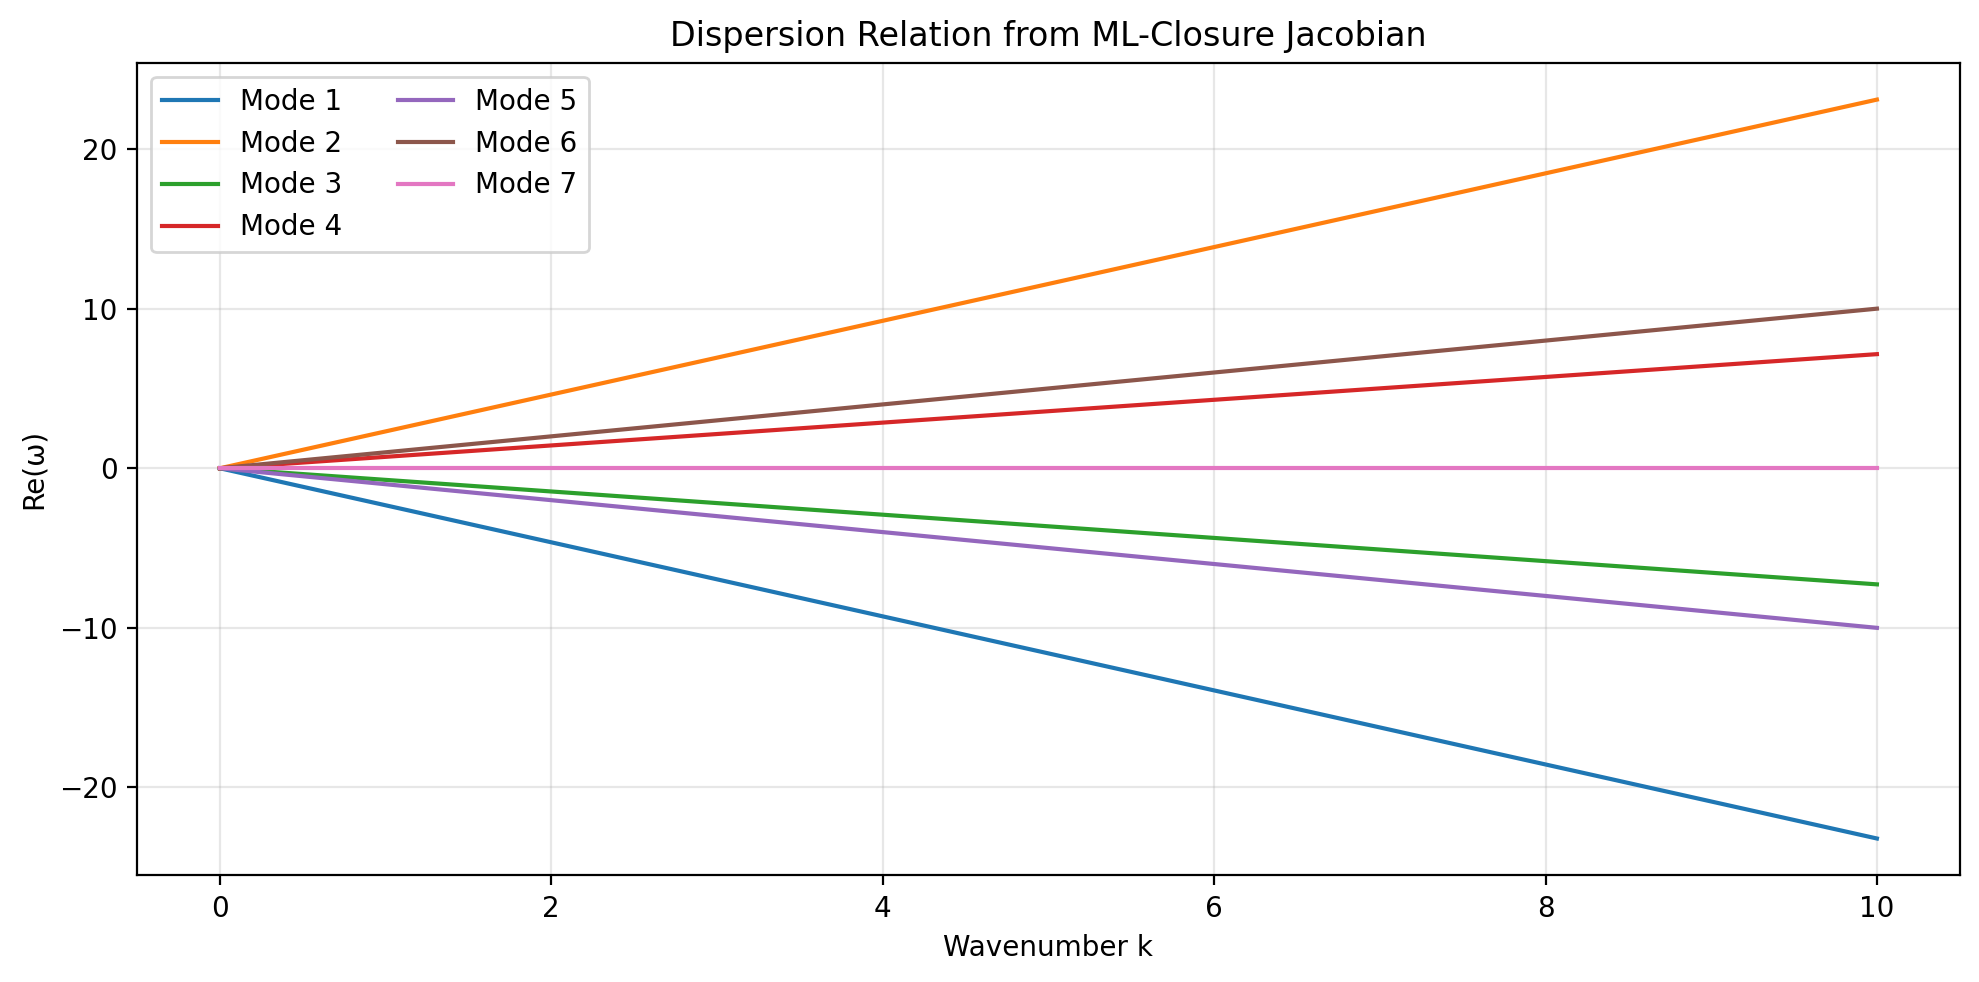

In [17]:
# Dispersion relation from user-chosen equilibrium (normalization-aware Jacobian)

def pressure_nn(rho, u1, u2, u3, B1, B2, B3, net):
    # Raw -> normalized features
    X = torch.stack([rho, u1, u2, u3, B1, B2, B3], dim=-1)

    # Force feature stats to 1D [7] to keep scalar inputs scalar after normalization
    x_mean = ml_x_mean_t.to(device=X.device, dtype=X.dtype).reshape(-1)
    x_std = ml_x_std_t.to(device=X.device, dtype=X.dtype).reshape(-1)

    # Force target stats to scalar
    y_mean = ml_y_mean_t.to(device=X.device, dtype=X.dtype).reshape(-1)[0]
    y_std = ml_y_std_t.to(device=X.device, dtype=X.dtype).reshape(-1)[0]

    Xn = (X - x_mean) / x_std
    p_norm = net(Xn).squeeze(-1)
    p = p_norm * y_std + y_mean
    return p

def flux_mhd(Q, net):
    # Q = [rho, rho*u1, rho*u2, rho*u3, B1, B2, B3]
    rho = Q[0]
    m1 = Q[1]
    m2 = Q[2]
    m3 = Q[3]
    B1 = Q[4]
    B2 = Q[5]
    B3 = Q[6]

    rho_safe = torch.clamp(rho, min=1e-8)
    u1 = m1 / rho_safe
    u2 = m2 / rho_safe
    u3 = m3 / rho_safe

    p = pressure_nn(rho_safe, u1, u2, u3, B1, B2, B3, net)
    Bsq = B1**2 + B2**2 + B3**2
    pmag = 0.5 * Bsq

    F1 = m1
    F2 = m1*u1 + p + pmag - B1*B1
    F3 = m1*u2 - B1*B2
    F4 = m1*u3 - B1*B3
    F5 = u1*B1 - u1*B1
    F6 = u1*B2 - u2*B1
    F7 = u1*B3 - u3*B1
    return torch.stack([F1, F2, F3, F4, F5, F6, F7])

def dispersion_from_jacobian_mhd(rho0, u10, u20, u30, B1_0, B2_0, B3_0, net, ks=None):
    """
    Compute Jacobian A0 = dF/dQ at a user-specified equilibrium state and
    return A0, eigvals, and omega(k)=k*eigvals.
    """
    if ks is None:
        ks = [0.1, 1.0, 10.0]

    Q0 = torch.tensor(
        [rho0, rho0*u10, rho0*u20, rho0*u30, B1_0, B2_0, B3_0],
        dtype=torch.double,
        device=ml_device,
        requires_grad=True,
    )

    model_d = net.to(ml_device).double()
    model_d.eval()

    def F_of_Q(Q):
        return flux_mhd(Q, model_d)

    A0 = torch.autograd.functional.jacobian(F_of_Q, Q0)
    eigvals = torch.linalg.eigvals(A0)
    omegas = torch.outer(torch.tensor(ks, dtype=torch.double, device=ml_device), eigvals)

    return A0.detach(), eigvals.detach(), omegas.detach(), Q0.detach()

if 'ml_model' not in globals() or 'ml_x_mean_t' not in globals():
    print("ML model/normalization stats not found. Run Cell 20 first.")
else:
    A0, eigvals, omegas, Q0 = dispersion_from_jacobian_mhd(
        rho0=1.0,
        u10=0.0,
        u20=0.0,
        u30=0.0,
        B1_0=1.0,
        B2_0=1.0,
        B3_0=1.0,
        net=ml_model,
        ks=[0.1, 1.0, 10.0],
    )

    A0_np = A0.cpu().numpy()
    eigvals_np = eigvals.cpu().numpy()

    print("=" * 60)
    print("JACOBIAN ANALYSIS (ML-based closure, normalized model)")
    print("=" * 60)
    print(f"\nJacobian shape: {tuple(A0.shape)}")
    print("\nEquilibrium state Q0 = [rho, mx, my, mz, Bx, By, Bz]:")
    print(Q0.cpu().numpy())

    print("\n" + "=" * 60)
    print("JACOBIAN MATRIX A0 = dF/dQ:")
    print("=" * 60)
    print(A0_np)

    print("\n" + "=" * 60)
    print("EIGENVALUES (characteristic speeds):")
    print("=" * 60)
    print("Real parts (sorted):")
    print(np.sort(np.real(eigvals_np)))
    print("\nImaginary parts:")
    print(np.sort(np.imag(eigvals_np)))
    print(f"\nMax imaginary part: {np.max(np.abs(np.imag(eigvals_np))):.6e}")

    ks_plot = np.linspace(0, 10, 200)
    omega_plot = np.outer(ks_plot, eigvals_np)

    plt.figure(figsize=(10, 5))
    for j in range(omega_plot.shape[1]):
        plt.plot(ks_plot, np.real(omega_plot[:, j]), lw=1.5, label=f'Mode {j+1}')
    plt.xlabel('Wavenumber k')
    plt.ylabel('Re(ω)')
    plt.title('Dispersion Relation from ML-Closure Jacobian')
    plt.grid(alpha=0.3)
    plt.legend(loc='best', ncol=2)
    plt.tight_layout()
    plt.show()

# Linear dispersion relations in ideal MHD (uniform plasma)

Assume a uniform equilibrium with constant density `ρ0`, pressure `p0`, magnetic field `B0`, and no flow.  
Take plane-wave perturbations

$$
\delta(\cdot)\propto \exp\!\left(i(\mathbf{k}\cdot\mathbf{x}-\omega t)\right).
$$

Define

$$
c_s^2=\gamma p_0/\rho_0,\qquad
v_A^2=\frac{B_0^2}{\mu_0\rho_0},\qquad
k_\parallel = k\cos\theta,
$$

where `θ` is the angle between `k` and `B0`.

---

## Alfvén mode

$$
\boxed{\ \omega^2 = k_\parallel^2\, v_A^2 = k^2 v_A^2 \cos^2\theta\ }
$$

---

## Magnetosonic modes (fast/slow)

They satisfy the quartic:

$$
\boxed{\ \omega^4 - k^2(c_s^2+v_A^2)\,\omega^2 + k^4 c_s^2 v_A^2 \cos^2\theta = 0\ }
$$

Equivalently, with phase speed \(v_{\rm ph}=\omega/k\):

$$
\boxed{\ v_{\rm ph}^2
= \frac{1}{2}\Big[(c_s^2+v_A^2)\ \pm\ \sqrt{(c_s^2+v_A^2)^2 - 4 c_s^2 v_A^2 \cos^2\theta}\Big]\ }
$$

- “+” : **fast** magnetosonic
- “−” : **slow** magnetosonic

---

## Special cases

### Parallel propagation $(\theta=0)$

$$
\omega^2 = k^2 v_A^2 \quad(\text{Alfvén}),
$$
$$
\omega^2 = k^2 c_s^2,\qquad
\omega^2 = k^2 v_A^2 \quad(\text{magnetosonic branches}).
$$

### Perpendicular propagation $(\theta=\pi/2)$

$$
\omega^2 = 0 \quad(\text{Alfvén; no propagation}),
$$
$$
\omega^2 = k^2(c_s^2+v_A^2) \quad(\text{fast}),
$$
$$
\omega^2 = 0 \quad(\text{slow; nonpropagating}).
$$